# INN Hotels Project

## Context

A significant number of hotel bookings are called-off due to cancellations or no-shows. The typical reasons for cancellations include change of plans, scheduling conflicts, etc. This is often made easier by the option to do so free of charge or preferably at a low cost which is beneficial to hotel guests but it is a less desirable and possibly revenue-diminishing factor for hotels to deal with. Such losses are particularly high on last-minute cancellations.

The new technologies involving online booking channels have dramatically changed customers’ booking possibilities and behavior. This adds a further dimension to the challenge of how hotels handle cancellations, which are no longer limited to traditional booking and guest characteristics.

The cancellation of bookings impact a hotel on various fronts:
* Loss of resources (revenue) when the hotel cannot resell the room.
* Additional costs of distribution channels by increasing commissions or paying for publicity to help sell these rooms.
* Lowering prices last minute, so the hotel can resell a room, resulting in reducing the profit margin.
* Human resources to make arrangements for the guests.

## Objective
The increasing number of cancellations calls for a Machine Learning based solution that can help in predicting which booking is likely to be canceled. INN Hotels Group has a chain of hotels in Portugal, they are facing problems with the high number of booking cancellations and have reached out to your firm for data-driven solutions. You as a data scientist have to analyze the data provided to find which factors have a high influence on booking cancellations, build a predictive model that can predict which booking is going to be canceled in advance, and help in formulating profitable policies for cancellations and refunds.

## Data Description
The data contains the different attributes of customers' booking details. The detailed data dictionary is given below.


**Data Dictionary**

* Booking_ID: unique identifier of each booking
* no_of_adults: Number of adults
* no_of_children: Number of Children
* no_of_weekend_nights: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
* no_of_week_nights: Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel
* type_of_meal_plan: Type of meal plan booked by the customer:
    * Not Selected – No meal plan selected
    * Meal Plan 1 – Breakfast
    * Meal Plan 2 – Half board (breakfast and one other meal)
    * Meal Plan 3 – Full board (breakfast, lunch, and dinner)
* required_car_parking_space: Does the customer require a car parking space? (0 - No, 1- Yes)
* room_type_reserved: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels.
* lead_time: Number of days between the date of booking and the arrival date
* arrival_year: Year of arrival date
* arrival_month: Month of arrival date
* arrival_date: Date of the month
* market_segment_type: Market segment designation.
* repeated_guest: Is the customer a repeated guest? (0 - No, 1- Yes)
* no_of_previous_cancellations: Number of previous bookings that were canceled by the customer prior to the current booking
* no_of_previous_bookings_not_canceled: Number of previous bookings not canceled by the customer prior to the current booking
* avg_price_per_room: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)
* no_of_special_requests: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)
* booking_status: Flag indicating if the booking was canceled or not.

## Importing necessary libraries and data

In [1]:
# Uncomment and run the following line if Google Colab is being used
#!pip install pandas==1.5.3 numpy==1.25.2 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 statsmodels==0.14.1 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [2]:
# Suppress warnings for clean class submission
import warnings
warnings.filterwarnings("ignore")

#Data Handling
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Remove limit of displayed columns
pd.set_option("display.max_columns", None)
# Limit number of displayed rows
pd.set_option("display.max_rows", 200)


# Build Prediction Models
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# Metric Scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
    make_scorer
)

#Format floats in pandas to 2 decimal places
pd.set_option("display.float_format", lambda x: "%.2f" % x)

## Load Data

In [3]:
#Import Data
Data_Original=pd.read_csv('INNHotelsGroup.csv')

In [4]:
#Create Copy to protect Original during manipulation
df=Data_Original.copy()

## Data Overview

- Observations
- Sanity checks

In [5]:
#Display first few rows, check load
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [6]:
#Get shape of data set
print('The dataframe has ', df.shape[0], 'rows and ', df.shape[1], 'columns.')

The dataframe has  36275 rows and  19 columns.


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [8]:
#Check for Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [9]:
#Checking there are no duplicated booking numbers - possible error indicator
df['Booking_ID'].is_unique

True

In [10]:
#Check for Null Values
df.isnull().sum()

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [11]:
#Check uniqe values in Object columns
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].unique())


Booking_ID
['INN00001' 'INN00002' 'INN00003' ... 'INN36273' 'INN36274' 'INN36275']

type_of_meal_plan
['Meal Plan 1' 'Not Selected' 'Meal Plan 2' 'Meal Plan 3']

room_type_reserved
['Room_Type 1' 'Room_Type 4' 'Room_Type 2' 'Room_Type 6' 'Room_Type 5'
 'Room_Type 7' 'Room_Type 3']

market_segment_type
['Offline' 'Online' 'Corporate' 'Aviation' 'Complementary']

booking_status
['Not_Canceled' 'Canceled']


In [12]:
#Statistical Summary of Data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.00,1.84,0.52,0.00,2.00,2.00,2.00,4.00
no_of_children,36275.00,0.11,0.40,0.00,0.00,0.00,0.00,10.00
no_of_weekend_nights,36275.00,0.81,0.87,0.00,0.00,1.00,2.00,7.00
no_of_week_nights,36275.00,2.20,1.41,0.00,1.00,2.00,3.00,17.00
required_car_parking_space,36275.00,0.03,0.17,0.00,0.00,0.00,0.00,1.00
lead_time,36275.00,85.23,85.93,0.00,17.00,57.00,126.00,443.00
arrival_year,36275.00,2017.82,0.38,2017.00,2018.00,2018.00,2018.00,2018.00
arrival_month,36275.00,7.42,3.07,1.00,5.00,8.00,10.00,12.00
arrival_date,36275.00,15.60,8.74,1.00,8.00,16.00,23.00,31.00
repeated_guest,36275.00,0.03,0.16,0.00,0.00,0.00,0.00,1.00


##### Data Overview Observations:

- The data provides the number of previous cancellations and the number of bookings not canceled.  It may be useful to create a column from these for the rate of cancellation (canceled/total_booked)
- There are no null values, 5 Object type values, and 13 integer type values, and 1 Float type value
- Booking_ID will not be useful in our modeling, so we used this to confirm there are not duplicates and will now drop it
- required_car_parking_space and repeated_guest are integers, but it is important to note this does not represent number of spaces or number of repeat guests.  Instead 0 = no and 1 = yes for if a space is required or if this is a repeat guest.
- There are no duplicated rows or duplicate booking IDs
- min number of adults on a booking being 0 and min price per room of 0 seem odd, we will look into these further
- This data covers the period of 2017 and 2018

In [13]:
#Drop Booking_ID for cleaner EDA and confirm drop
df=df.drop('Booking_ID', axis=1)
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


## Functions used in this Project

In [14]:
def plot_distribution(df, column, xlabel='Value', color='steelblue'):
    """
    Plots a horizontal boxplot and histogram with KDE for a given column.
    Adds mean and median lines to the histogram.

    Parameters:
        df      : pandas DataFrame
        column  : string, name of the column to plot
        xlabel  : string, label for the x-axis (default: 'Value')
        color   : string, color for the histogram (default: 'steelblue')
    """
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))

    # Horizontal Boxplot
    axes[0].boxplot(df[column].dropna(), vert=False)
    axes[0].set_title(f'Boxplot of {column}')
    axes[0].set_xlabel(xlabel)

    # Histogram with KDE
    sns.histplot(df[column].dropna(), bins=30, color=color, kde=True, ax=axes[1])

    # Mean and median lines
    mean_val = df[column].mean()
    median_val = df[column].median()
    axes[1].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    axes[1].axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.2f}')
    axes[1].legend()
    axes[1].set_title(f'Distribution of {column}')
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel('Frequency')

    plt.suptitle(f'{column} - Distribution Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [15]:
def plot_box_count(df, column, xlabel='Value', color='steelblue'):
    """
    Plots a horizontal boxplot and countplot for a given column.
    Adds mean and median lines to the boxplot.

    Parameters:
        df      : pandas DataFrame
        column  : string, name of the column to plot
        xlabel  : string, label for the x-axis (default: 'Value')
        color   : string, color for the histogram (default: 'steelblue')
    """
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))

    # Horizontal Boxplot
    axes[0].boxplot(df[column].dropna(), vert=False)
    axes[0].set_title(f'Boxplot of {column}')
    axes[0].set_xlabel(xlabel)

    # Countplot
    sns.countplot(data=df, x=column, color=color, ax=axes[1])

    # Mean and median lines
    mean_val = df[column].mean()
    median_val = df[column].median()
    axes[1].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    axes[1].axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.2f}')
    axes[1].legend()
    axes[1].set_title(f'Distribution of {column}')
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel('Frequency')

    plt.suptitle(f'{column} - Distribution Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [16]:
def describe_distribution(df, column):
    """
    Prints IQR-based outlier fences, outlier count, skewness interpretation,
    and descriptive statistics for a given column.

    Parameters:
        df      : pandas DataFrame
        column  : string, name of the column to analyze
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    print('Lower Outlier Fence =', Q1 - 1.5 * IQR)
    print('Upper Outlier Fence =', Q3 + 1.5 * IQR)
    outliers = df[(df[column] < Q1 - 1.5*IQR) |
                  (df[column] > Q3 + 1.5*IQR)]
    print(f"Outlier count: {len(outliers)}")

    print('Skewness: ', df[column].skew())
    if df[column].skew() < -1:
        print('The distribution is highly skewed to the left.')
    elif df[column].skew() > 1:
        print('The distribution is highly skewed to the right.')
    elif df[column].skew() > 0.5:
        print('The distribution is moderately skewed to the right.')
    elif df[column].skew() < -0.5:
        print('The distribution is moderately skewed to the left.')
    else:
        print('The distribution is approximately symmetric.')

    display(df[column].describe())

In [17]:
def find_correlations(df, threshold):
    """
    Returns pairs of numeric variables whose absolute correlation
    exceeds the specified threshold.

    Parameters:
        df (DataFrame): Input dataframe
        threshold (float): Minimum absolute correlation to return

    Returns:
        Series of correlation pairs sorted by absolute correlation
    """
    
    corr = df.select_dtypes(include='number').corr()
    #Upper triangle mask to hide duplicates
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

    strong_corr = (
        corr.where(mask)
            .stack()
            .loc[lambda x: abs(x) > threshold]
            .sort_values(key=abs, ascending=False)
    )

    return strong_corr

In [18]:
def check_vif(X):
    """
    Calculates Variance Inflation Factor (VIF) for each feature.
    VIF > 5 indicates moderate multicollinearity.
    VIF > 10 indicates high multicollinearity.
    
    Parameters:
        X : DataFrame of independent variables (with constant added)
    
    Returns:
        DataFrame of features and their VIF scores, sorted descending
    """
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                       for i in range(X.shape[1])]
    
    return vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

In [19]:
def evaluate_model(model_name, model, X, y, threshold=0.5):
    """
    Evaluates a fitted statsmodels or sklearn model and prints a clean 
    performance summary including accuracy, recall, precision, F1, and ROC-AUC.
    Also displays a confusion matrix.
    
    Parameters:
        model_name : string, label for the model (e.g. 'lg1', 'lg2')
        model      : fitted model object
        X          : feature matrix (use X_train_const/X_test_const for statsmodels)
        y          : true labels
        threshold  : classification threshold (default 0.5)
    
    Returns:
        dict of metrics
    """
    # Handle both statsmodels and sklearn predict methods
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X)[:, 1]
    else:
        y_prob = model.predict(X)
    
    y_pred = (y_prob >= threshold).astype(int)
    
    # Metrics
    acc  = accuracy_score(y, y_pred)
    rec  = recall_score(y, y_pred)
    pre  = precision_score(y, y_pred)
    f1   = f1_score(y, y_pred)
    auc  = roc_auc_score(y, y_prob)
    
    # Print summary
    print("=" * 40)
    print(f"  Model: {model_name}")
    print("=" * 40)
    print(f"  {'Accuracy':<12} {acc:>10.4f}")
    print(f"  {'Recall':<12} {rec:>10.4f}")
    print(f"  {'Precision':<12} {pre:>10.4f}")
    print(f"  {'F1 Score':<12} {f1:>10.4f}")
    print(f"  {'ROC-AUC':<12} {auc:>10.4f}")
    print("=" * 40)
    
    # Confusion Matrix
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                  display_labels=['Not Canceled', 'Canceled'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {model_name}')
    plt.tight_layout()
    plt.show()

    # Return metrics as dictionary
    return {
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Recall': round(rec, 4),
        'Precision': round(pre, 4),
        'F1 Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    }

In [20]:
# Automated backward elimination - drops highest p-value iteratively until all < 0.05
def backward_elimination(X_train, X_test, y_train, threshold=0.05):
    """
    Iteratively drops the feature with the highest p-value until
    all remaining features are below the significance threshold.
    
    Parameters:
        X_train   : training features (with constant)
        X_test    : test features (with constant)
        y_train   : training target
        threshold : p-value cutoff (default 0.05)
    
    Returns:
        fitted final model, X_train_final, X_test_final
    """
    X_train_work = X_train.copy()
    X_test_work  = X_test.copy()
    iteration = 1
    
    while True:
        model = sm.Logit(y_train, X_train_work).fit(disp=False, maxiter=500)
        pvalues = model.pvalues.drop('const', errors='ignore')
        
        max_pval = pvalues.max()
        max_feat = pvalues.idxmax()
        
        if max_pval <= threshold:
            print(f"All features significant. Final model reached in {iteration-1} iterations.")
            break
            
        print(f"Iteration {iteration}: Dropping '{max_feat}' (p={max_pval:.4f})")
        X_train_work = X_train_work.drop(columns=[max_feat])
        X_test_work  = X_test_work.drop(columns=[max_feat])
        iteration += 1
    
    return model, X_train_work, X_test_work

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**:
1. What are the busiest months in the hotel?
   A: August to October with October having the most bookings.
2. Which market segment do most of the guests come from?
   A: Online Bookings
3. Hotel rates are dynamic and change according to demand and customer demographics. What are the differences in room prices in different market segments?
   A: Average price is highest in the Online segment, and lowest in the Complementary segment.
4. What percentage of bookings are canceled?
   A: 33%
5. Repeating guests are the guests who stay in the hotel often and are important to brand equity. What percentage of repeating guests cancel?
    A: 2%
6. Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation?
    A: Outliers with 3 or more special requests appear to be less prone to cancellation, but otherwise the data for cancellation by number of requests is fairly similar.  These outliers are also not a large enough set (2% of the data) to draw reliable conclusions from.

### Univariate EDA

#### Number of Adults

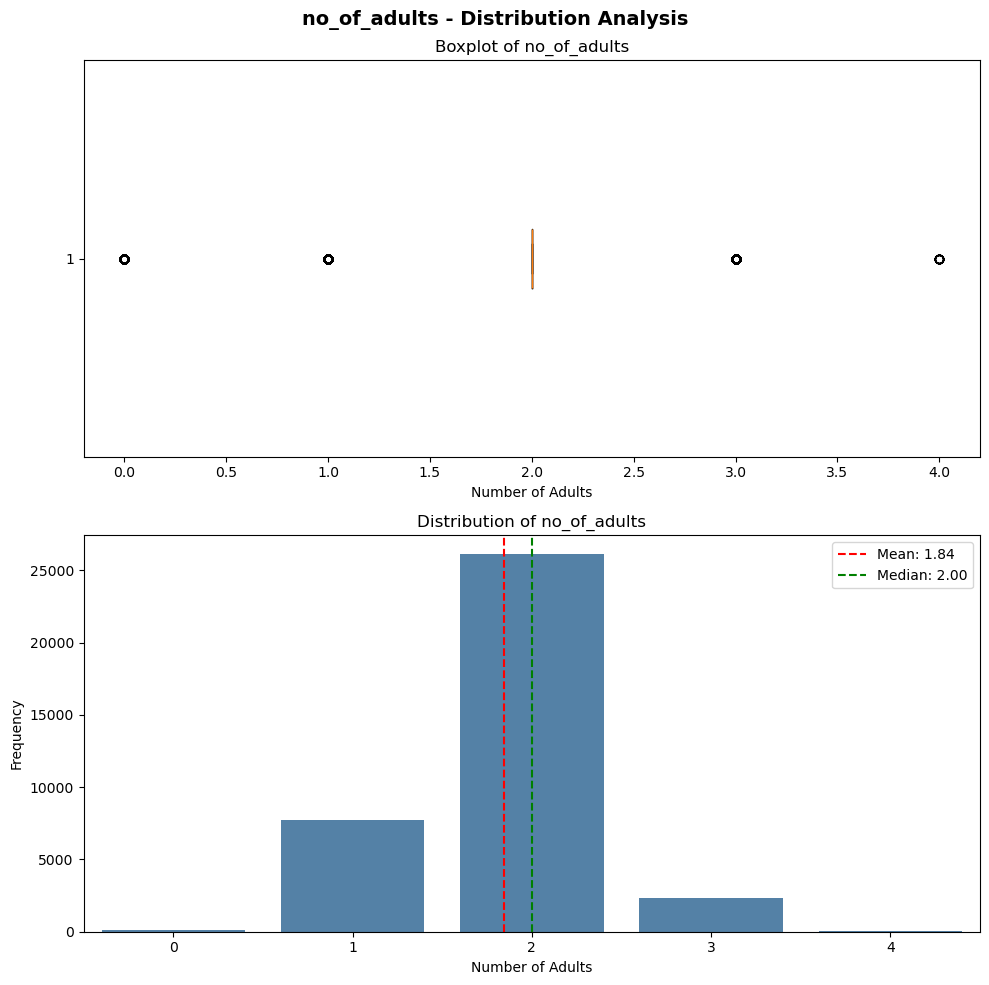

In [21]:
plot_box_count(df, 'no_of_adults', xlabel='Number of Adults')

In [22]:
describe_distribution(df, 'no_of_adults')

Lower Outlier Fence = 2.0
Upper Outlier Fence = 2.0
Outlier count: 10167
Skewness:  -0.3332949302307013
The distribution is approximately symmetric.


count   36275.00
mean        1.84
std         0.52
min         0.00
25%         2.00
50%         2.00
75%         2.00
max         4.00
Name: no_of_adults, dtype: float64

In [23]:
#Check 0 values in no_of_adults
print('There are ', (df['no_of_adults']==0).sum(), ' bookings showing 0 adults')

There are  139  bookings showing 0 adults


#### Number of Adults Observations:
- As expected the majority of bookings have 1 or 2 adults on them.
- 139 Bookings show 0 adults.  This stands out as odd, but it could be the case that these are rooms booked by parents for their children in adjacent rooms, or parents booking rooms for teenagers on school trips.  If this were a real work project I would inquire further with INNHotels on the meaning in order to determine whether to treat the data.  For this class project, since these could be valid data points and there is no way for me to verify them, I will leave them untreated.
- Other outliers appear to be legitimate data and will not be treated.

#### Number of Children

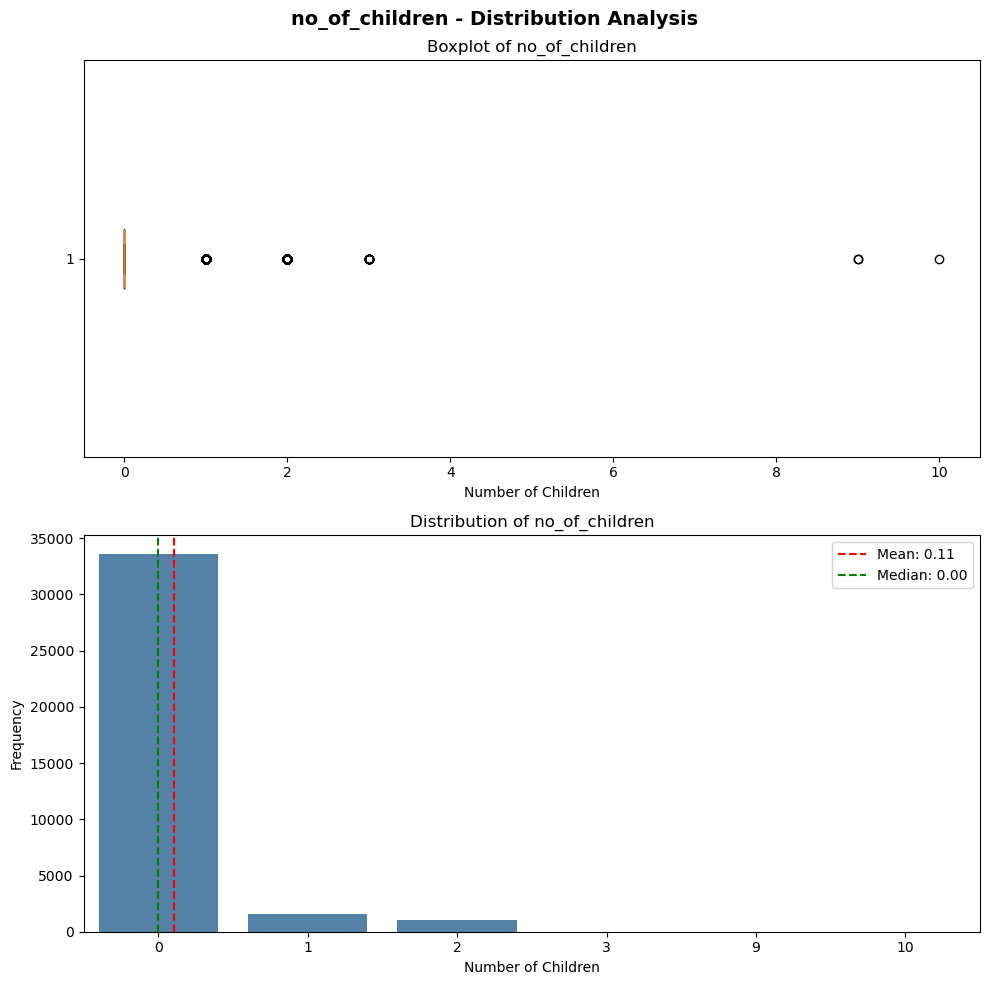

In [24]:
plot_box_count(df, 'no_of_children', xlabel='Number of Children')

In [25]:
describe_distribution(df, 'no_of_children')

Lower Outlier Fence = 0.0
Upper Outlier Fence = 0.0
Outlier count: 2698
Skewness:  4.710349518506961
The distribution is highly skewed to the right.


count   36275.00
mean        0.11
std         0.40
min         0.00
25%         0.00
50%         0.00
75%         0.00
max        10.00
Name: no_of_children, dtype: float64

#### Number of Children Observations:
- Number of children on a booking ranges from 0 to 10 with 0 being by far the most frequent.
- Outliers appear to be legitimate data and will not be treated

#### Number of Weekend Nights

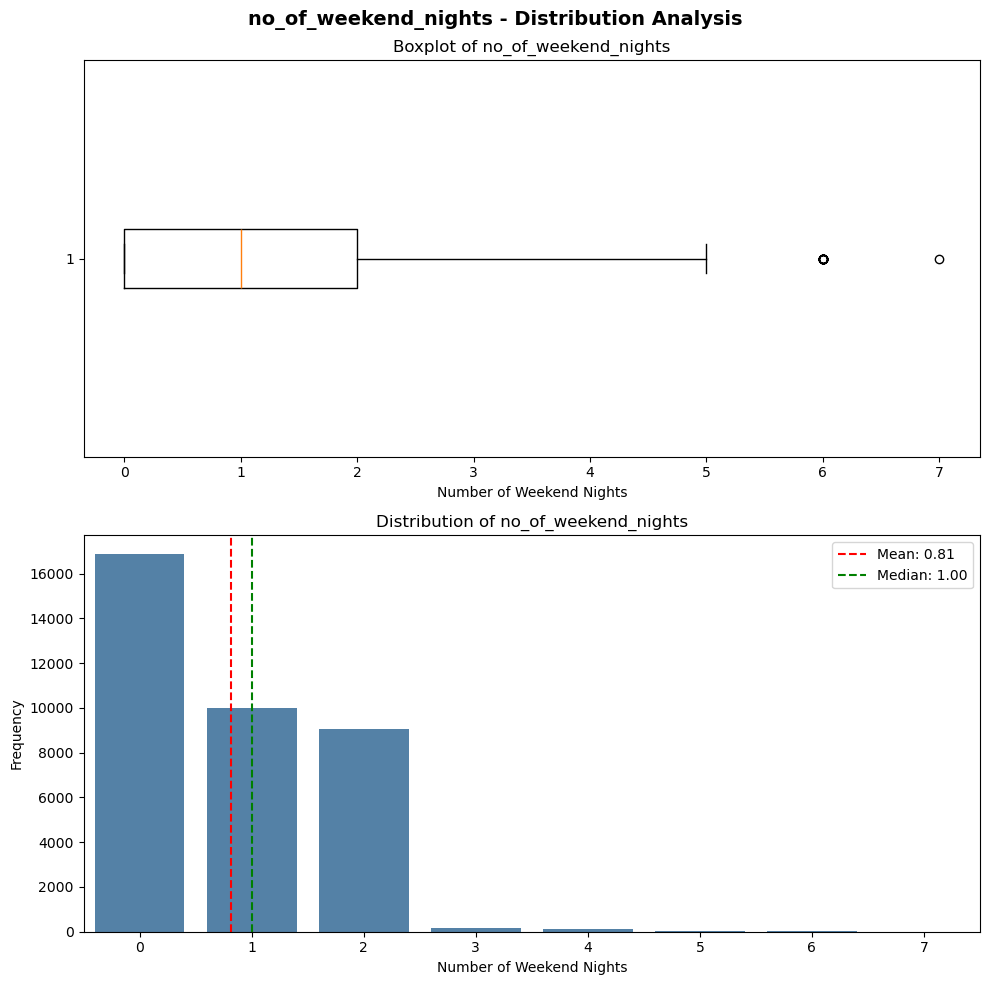

In [26]:
plot_box_count(df, 'no_of_weekend_nights', xlabel='Number of Weekend Nights')

In [27]:
describe_distribution(df, 'no_of_weekend_nights')

Lower Outlier Fence = -3.0
Upper Outlier Fence = 5.0
Outlier count: 21
Skewness:  0.7376159576059308
The distribution is moderately skewed to the right.


count   36275.00
mean        0.81
std         0.87
min         0.00
25%         0.00
50%         1.00
75%         2.00
max         7.00
Name: no_of_weekend_nights, dtype: float64

#### Number of Weekend Nights Observations:
- 75% of bookings have 0-2 weekend nights leaving only 25% of stays extending longer than a full week.
- Outliers appear to be legitimate data and will not be treated

#### Number of Week Nights

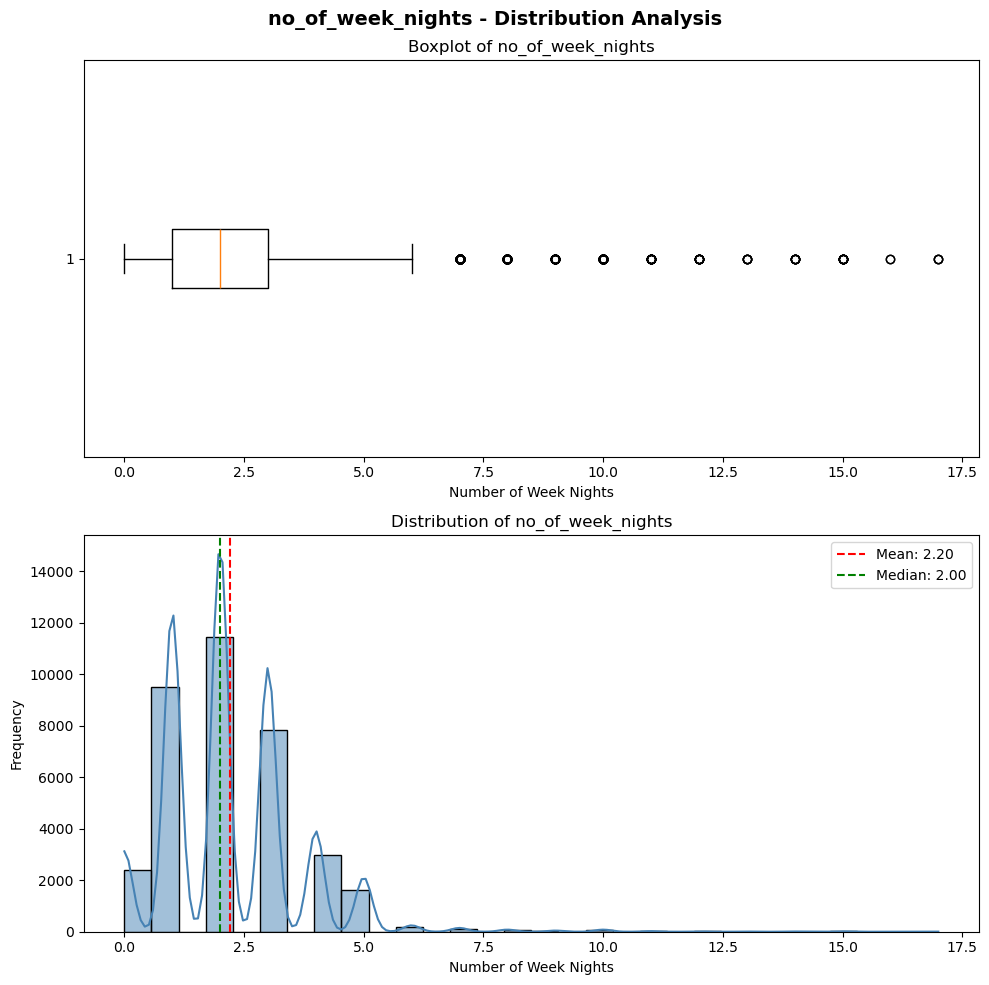

In [28]:
plot_distribution(df, 'no_of_week_nights', xlabel='Number of Week Nights')

In [29]:
describe_distribution(df, 'no_of_week_nights')

Lower Outlier Fence = -2.0
Upper Outlier Fence = 6.0
Outlier count: 324
Skewness:  1.5993503651924639
The distribution is highly skewed to the right.


count   36275.00
mean        2.20
std         1.41
min         0.00
25%         1.00
50%         2.00
75%         3.00
max        17.00
Name: no_of_week_nights, dtype: float64

#### Number of Week Nights Observations:
- Bookings ranged from 0 to 17 weeknights with 75% of bookings having 3 or fewer weeknights.
- It would be of interest to know the total number of nights on a booking - let's find that.
- Outliers appear to be legitimate data and will not be treated.

#### Create and Check Total Nights Booked

In [30]:
#Create a column for total nights on a booking
df['total_nights'] = (df['no_of_week_nights']+ df['no_of_weekend_nights'])
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_nights
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled,3
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled,5
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled,3
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled,2
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled,2


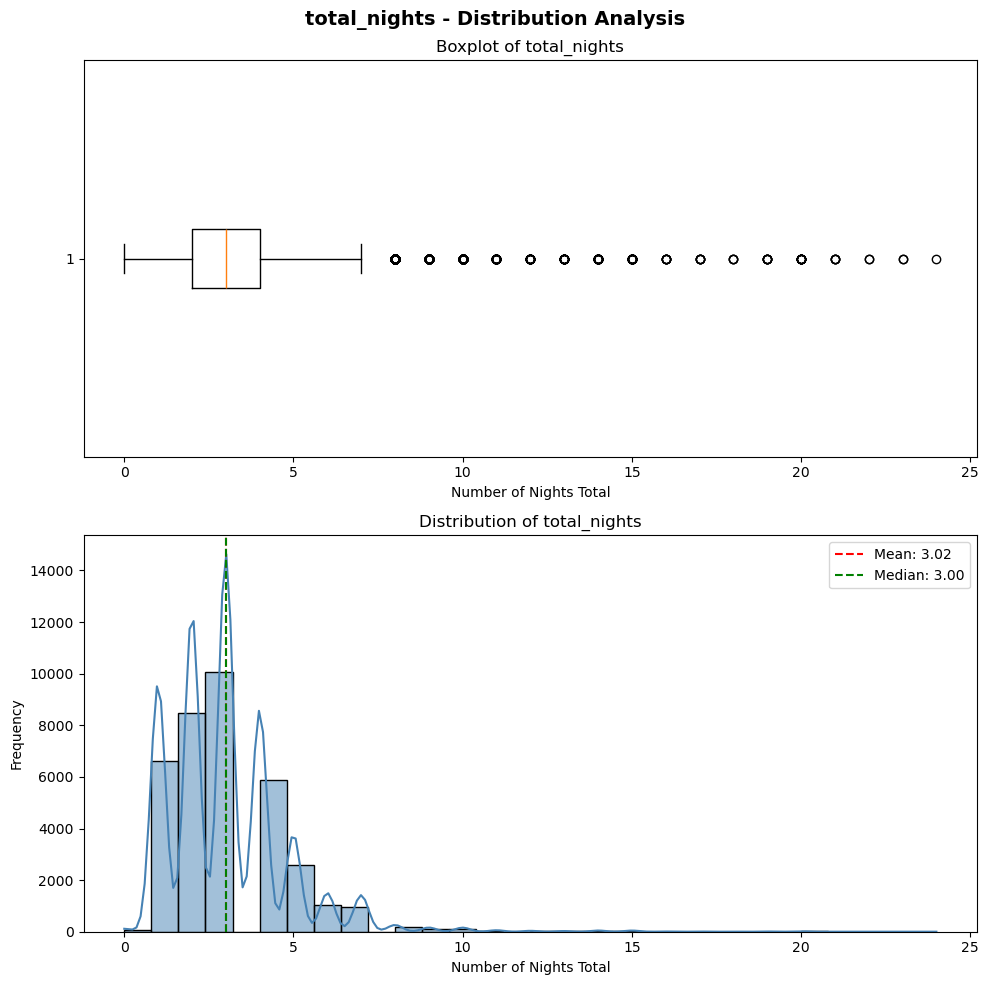

In [31]:
plot_distribution(df, 'total_nights', xlabel='Number of Nights Total')

In [32]:
describe_distribution(df, 'total_nights')

Lower Outlier Fence = -1.0
Upper Outlier Fence = 7.0
Outlier count: 583
Skewness:  2.23281635167205
The distribution is highly skewed to the right.


count   36275.00
mean        3.02
std         1.79
min         0.00
25%         2.00
50%         3.00
75%         4.00
max        24.00
Name: total_nights, dtype: float64

#### Total Nights Observations:
- Bookings ranged from 0 to 24 total nights
- 0 Total nights on a booking seems odd, let's take a closer look

In [33]:
#Check 0 values in total_nights
print('There are ', (df['total_nights']==0).sum(), ' bookings showing 0 Total Nights booked')

There are  78  bookings showing 0 Total Nights booked


In [34]:
#Check if all of those bookings are showing 0 due to cancellation
print(((df['total_nights']==0) & (df['booking_status']=='Canceled')).sum(), 'of the bookings with 0 nights were Canceled')

2 of the bookings with 0 nights were Canceled


In [35]:
#Look for anything else odd about these 0 night stays
df[df['total_nights'] == 0].head(10)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_nights
209,1,0,0,0,Meal Plan 1,0,Room_Type 1,4,2018,2,27,Complementary,0,0,0,0.00,1,Not_Canceled,0
1158,2,0,0,0,Meal Plan 1,0,Room_Type 1,145,2018,7,5,Online,0,0,0,0.00,1,Not_Canceled,0
1403,3,0,0,0,Meal Plan 1,0,Room_Type 4,57,2018,4,1,Online,0,0,0,0.00,2,Not_Canceled,0
1907,2,0,0,0,Meal Plan 2,0,Room_Type 1,247,2018,6,6,Online,0,0,0,0.00,1,Not_Canceled,0
1986,2,0,0,0,Meal Plan 1,0,Room_Type 1,43,2017,10,17,Online,0,0,0,0.00,1,Not_Canceled,0
2088,2,0,0,0,Meal Plan 1,0,Room_Type 1,12,2018,8,16,Online,0,0,0,0.00,1,Not_Canceled,0
2472,2,0,0,0,Not Selected,0,Room_Type 1,19,2017,12,16,Online,0,0,0,0.00,0,Not_Canceled,0
2514,1,0,0,0,Meal Plan 1,0,Room_Type 7,7,2018,10,10,Online,0,0,0,0.00,1,Not_Canceled,0
2933,2,0,0,0,Meal Plan 1,0,Room_Type 1,274,2018,11,4,Online,0,0,0,0.00,2,Not_Canceled,0
3759,1,0,0,0,Meal Plan 1,0,Room_Type 1,56,2017,9,25,Online,0,0,0,0.00,0,Not_Canceled,0


We see an average price of 0 on these first 10.

In [36]:
#Check how many 0 night stays have an average price of 0
df[df['total_nights'] == 0]['avg_price_per_room'].value_counts()

avg_price_per_room
0.00    78
Name: count, dtype: int64

All 78 have an average price of 0, reinforcing that this is bad data.

#### Observations:
These records represent less than 0.25% of the dataset and simultaneously exhibit zero stay duration and zero room revenue while being classified as completed bookings. Because they do not represent meaningful hotel bookings and appear to originate from a different business process than normal reservations, or from entry error, and because they all contain what appear to be multiple errors (0 per room value even on rooms not canceled), I will remove them rather than impute.

In [37]:
#Remove the 78 invalid bookings
df = df[df['total_nights'] > 0]
#Check Removal
df.shape

(36197, 19)

#### Type of Meal Plan

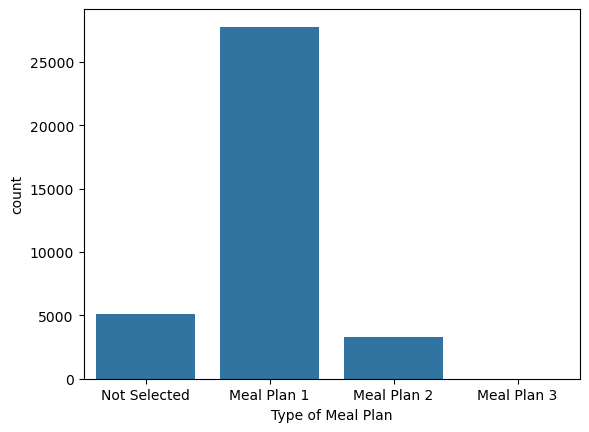

In [38]:
meal_plan_order= [
    'Not Selected',
    'Meal Plan 1',
    'Meal Plan 2',
    'Meal Plan 3'
    ]

sns.countplot(
    data=df,
    x='type_of_meal_plan',
    order=meal_plan_order
)
plt.xlabel('Type of Meal Plan')
plt.show()

In [39]:
df['type_of_meal_plan'].value_counts()

type_of_meal_plan
Meal Plan 1     27778
Not Selected     5114
Meal Plan 2      3300
Meal Plan 3         5
Name: count, dtype: int64

#### Meal Plan Observations:
- The vast majority select breakfast only as the meal plan with their booking.

#### Car Parking

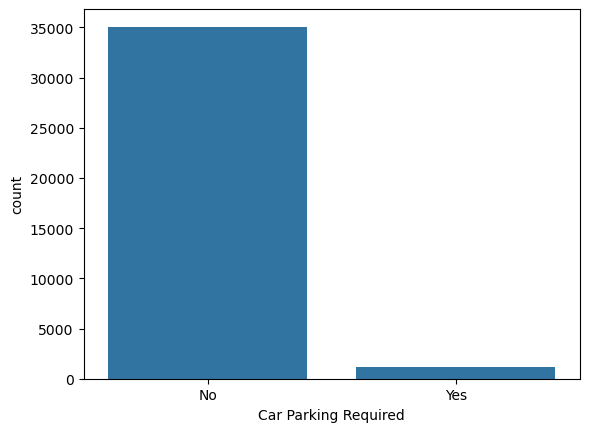

In [40]:
sns.countplot(df, x='required_car_parking_space').set_xticklabels(['No', 'Yes'])
plt.xlabel('Car Parking Required')
plt.show()

In [41]:
df['required_car_parking_space'].value_counts()

required_car_parking_space
0    35073
1     1124
Name: count, dtype: int64

#### Car Parking Observations:
- The vast majority of bookings did not require a car parking space.

#### Room Type

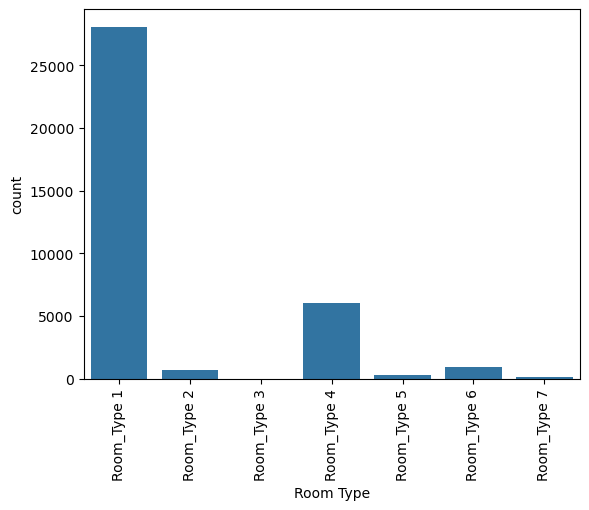

In [42]:
room_order = [
    'Room_Type 1',
    'Room_Type 2',
    'Room_Type 3',
    'Room_Type 4',
    'Room_Type 5',
    'Room_Type 6',
    'Room_Type 7'
]

sns.countplot(
    data=df,
    x='room_type_reserved',
    order=room_order
)

plt.xlabel('Room Type')
plt.xticks(rotation=90)
plt.show()

In [43]:
df['room_type_reserved'].value_counts()

room_type_reserved
Room_Type 1    28066
Room_Type 4     6048
Room_Type 6      964
Room_Type 2      690
Room_Type 5      265
Room_Type 7      157
Room_Type 3        7
Name: count, dtype: int64

#### Room Type Observations:
- Room Type 1 is the most popular to book.

#### Lead Time

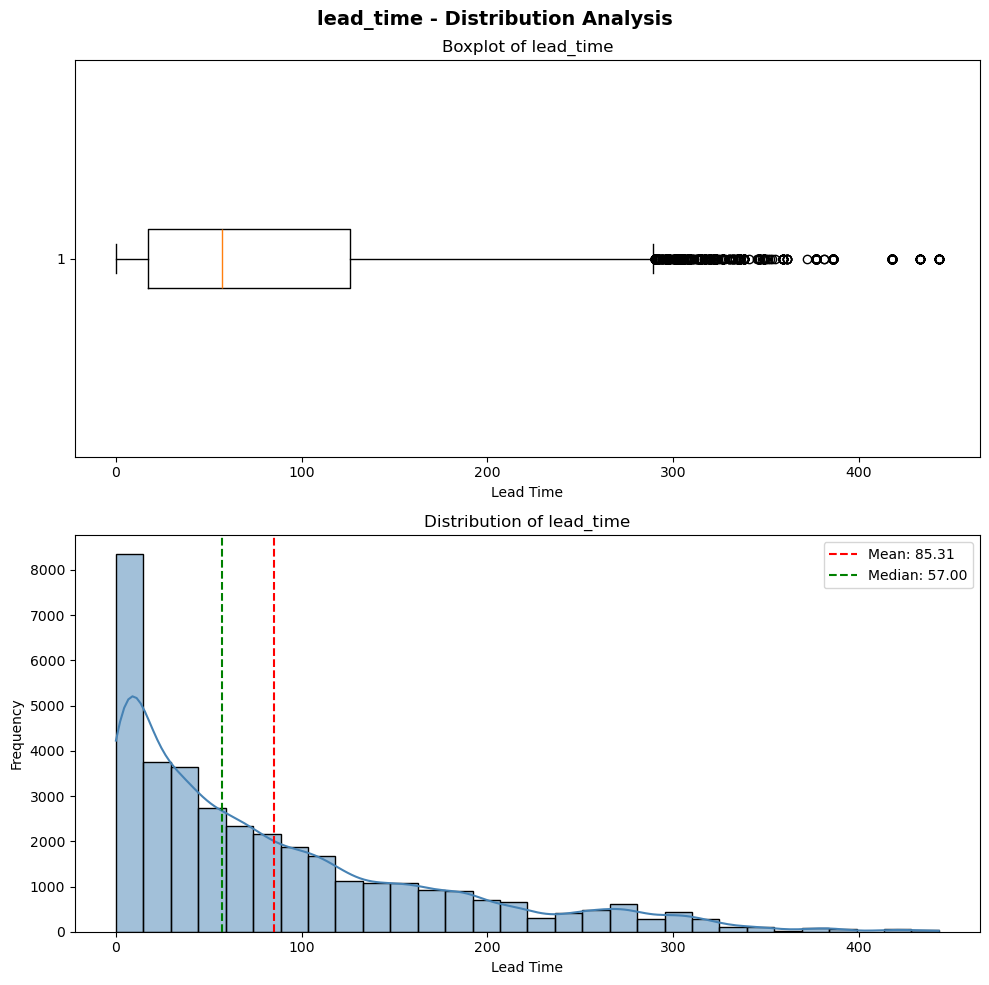

In [44]:
plot_distribution(df, 'lead_time', xlabel='Lead Time')

In [45]:
describe_distribution(df, 'lead_time')

Lower Outlier Fence = -146.5
Upper Outlier Fence = 289.5
Outlier count: 1330
Skewness:  1.2915237830937893
The distribution is highly skewed to the right.


count   36197.00
mean       85.31
std        85.94
min         0.00
25%        17.00
50%        57.00
75%       126.00
max       443.00
Name: lead_time, dtype: float64

#### Lead Time Observations:
- Lead time ranges from 0 days (same day booking) to 443 days (> 1 yr out planning) with the mean being about 86 days.
- Outliers appear to be legitimate data and will not be imputed.

#### Arrival Year

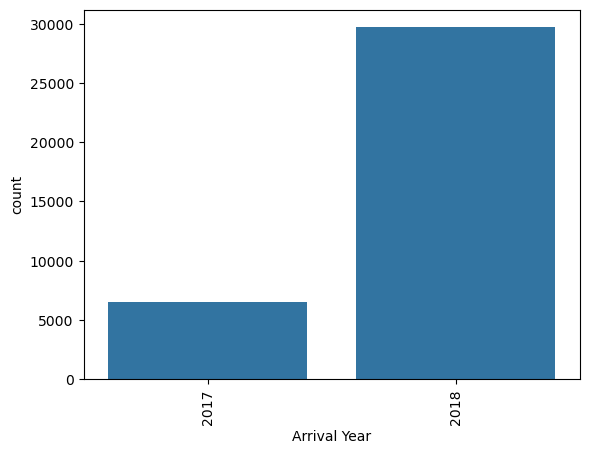

In [46]:
sns.countplot(
    data=df,
    x='arrival_year'
)
plt.xlabel('Arrival Year')
plt.xticks(rotation=90)
plt.show()

In [47]:
df['arrival_year'].value_counts()

arrival_year
2018    29706
2017     6491
Name: count, dtype: int64

#### Arrival Year Observations:
- The majority of bookings in this dataset are from 2018.

#### Arrival Month

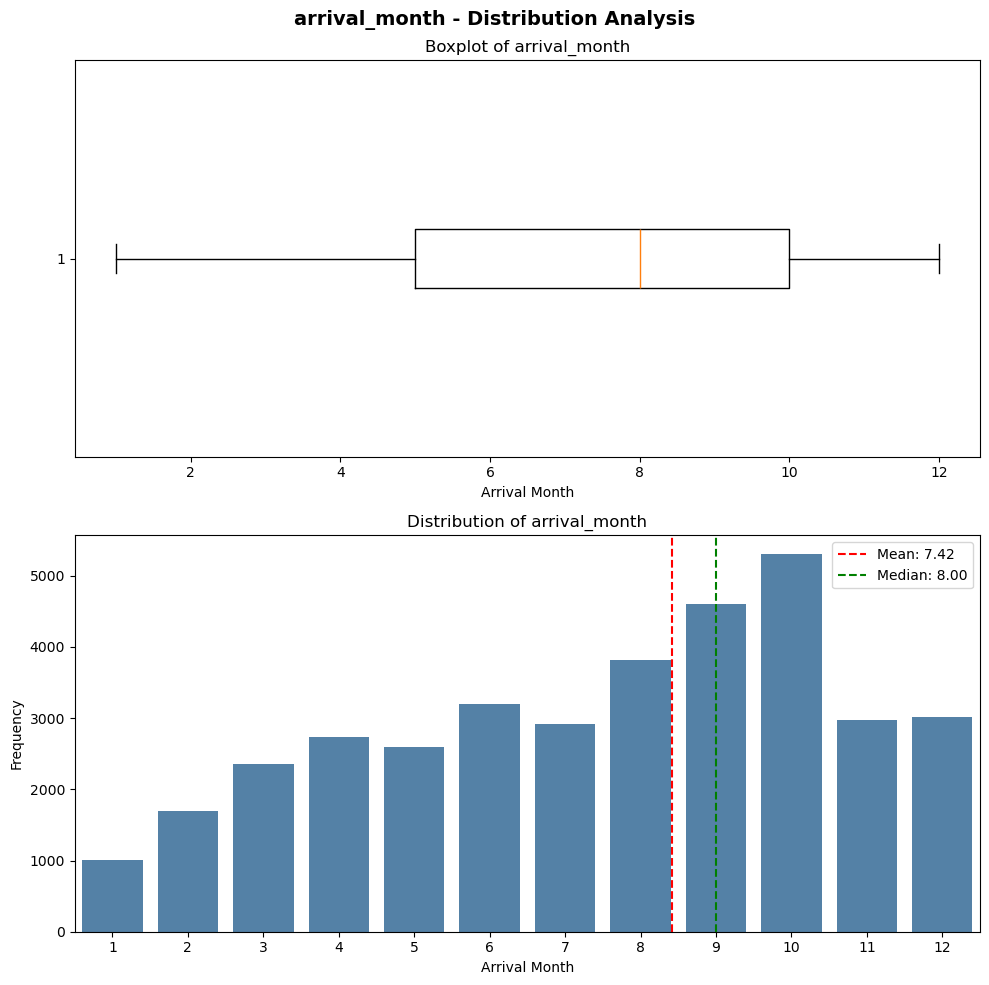

In [48]:
plot_box_count(df, 'arrival_month', xlabel='Arrival Month')

In [49]:
describe_distribution(df, 'arrival_month')

Lower Outlier Fence = -2.5
Upper Outlier Fence = 17.5
Outlier count: 0
Skewness:  -0.34780821871306905
The distribution is approximately symmetric.


count   36197.00
mean        7.42
std         3.07
min         1.00
25%         5.00
50%         8.00
75%        10.00
max        12.00
Name: arrival_month, dtype: float64

#### Arrival Month Observations:
- Bookings range all months of the year with the highest counts in the August to October timeframe. (Answer to Leading Question 1) 

#### Arrival Date

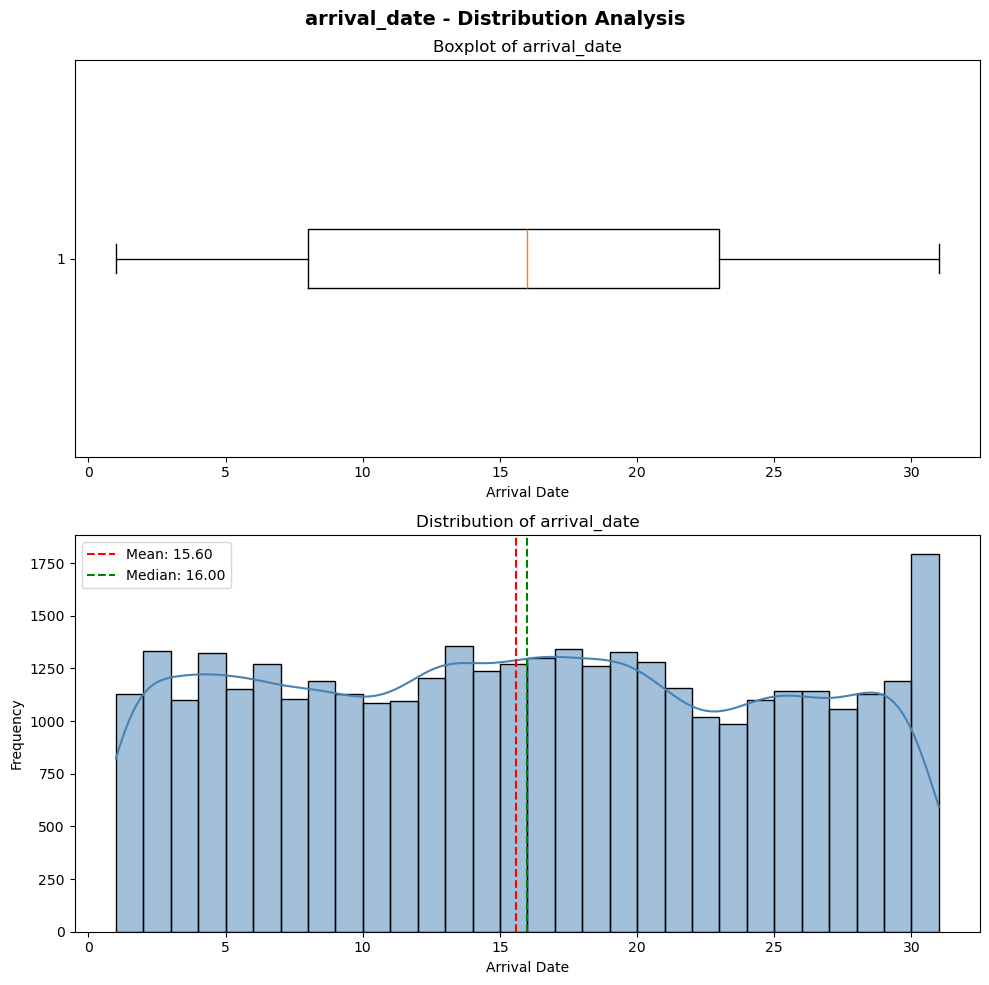

In [50]:
plot_distribution(df, 'arrival_date', xlabel='Arrival Date')

In [51]:
describe_distribution(df, 'arrival_date')

Lower Outlier Fence = -14.5
Upper Outlier Fence = 45.5
Outlier count: 0
Skewness:  0.028714612733164682
The distribution is approximately symmetric.


count   36197.00
mean       15.60
std         8.74
min         1.00
25%         8.00
50%        16.00
75%        23.00
max        31.00
Name: arrival_date, dtype: float64

#### Arrival Date Observations:
- Arrival dates span all days of the month and are fairly symmetric and even in distribution.

#### Market Segment

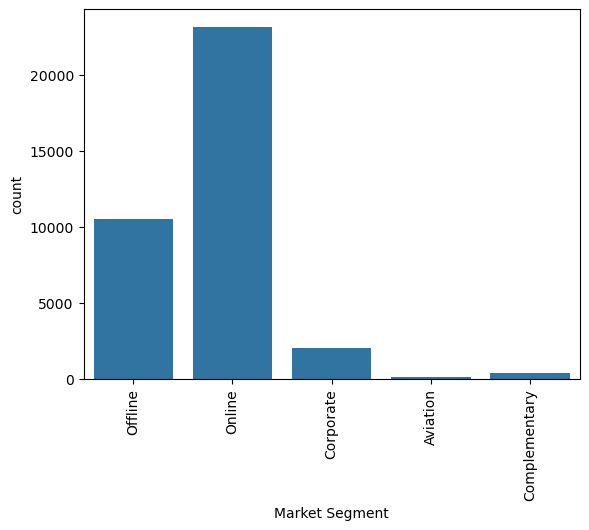

In [52]:
sns.countplot(
    data=df,
    x='market_segment_type'
)
plt.xlabel('Market Segment')
plt.xticks(rotation=90)
plt.show()

In [53]:
df['market_segment_type'].value_counts()

market_segment_type
Online           23149
Offline          10528
Corporate         2017
Complementary      378
Aviation           125
Name: count, dtype: int64

#### Market Segment Observations:
- As can be expected, the majority of bookings are done online (Answer to Leading Question 2)
- Later in multivariate analysis we will want to cross reference Complementary bookings with the 0 average price per room bookings

#### Repeat Guest

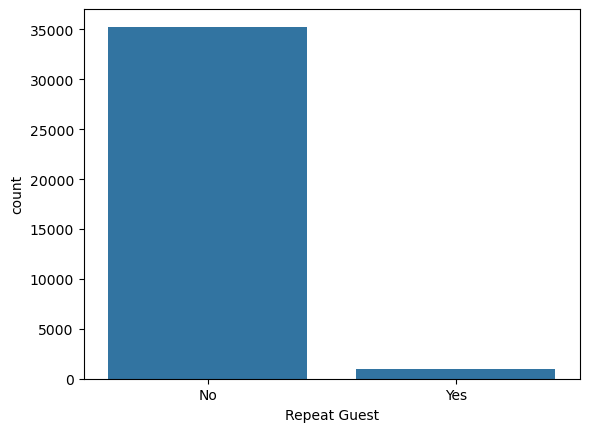

In [54]:
sns.countplot(df, x='repeated_guest').set_xticklabels(['No', 'Yes'])
plt.xlabel('Repeat Guest')
plt.show()

In [55]:
df['repeated_guest'].value_counts()

repeated_guest
0    35271
1      926
Name: count, dtype: int64

#### Repeat Guest Observations:
- A very small amount (2.6%) of bookings are repeat guests.

#### Number of Previous Cancellations

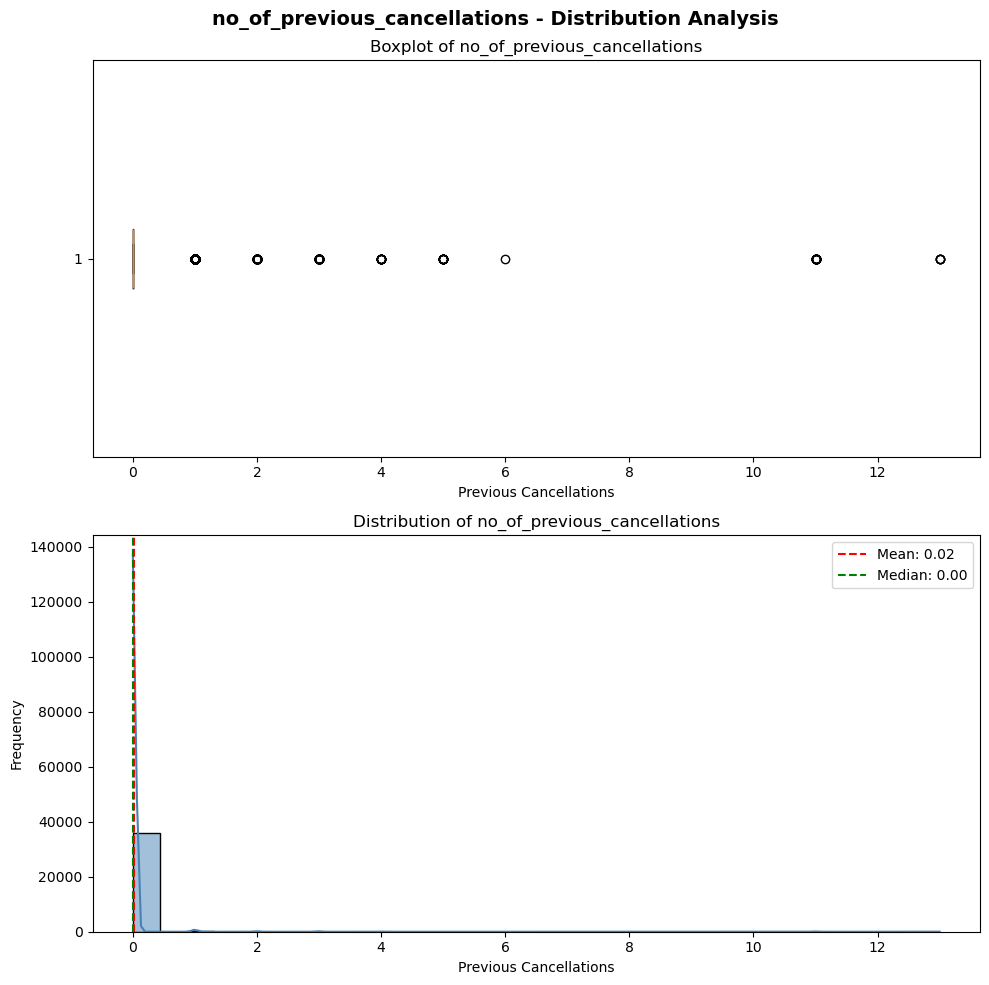

In [56]:
plot_distribution(df, 'no_of_previous_cancellations', xlabel='Previous Cancellations')

In [57]:
describe_distribution(df, 'no_of_previous_cancellations')

Lower Outlier Fence = 0.0
Upper Outlier Fence = 0.0
Outlier count: 337
Skewness:  25.179715833577596
The distribution is highly skewed to the right.


count   36197.00
mean        0.02
std         0.37
min         0.00
25%         0.00
50%         0.00
75%         0.00
max        13.00
Name: no_of_previous_cancellations, dtype: float64

In [58]:
df['no_of_previous_cancellations'].value_counts()

no_of_previous_cancellations
0     35860
1       197
2        46
3        43
11       25
5        11
4        10
13        4
6         1
Name: count, dtype: int64

In [59]:
print('There are', (df['no_of_previous_cancellations'] > 0).sum(), 'bookings with at least 1 previous cancellation')

There are 337 bookings with at least 1 previous cancellation


#### Previous Cancellations Observations:
- ~99% of bookings in this dataset have 0 previous cancellations
- There is a small number of outliers with 2-13 cancellations.  These are legitimate data points and will not be treated.

#### Number of Previous Bookings Not Canceled

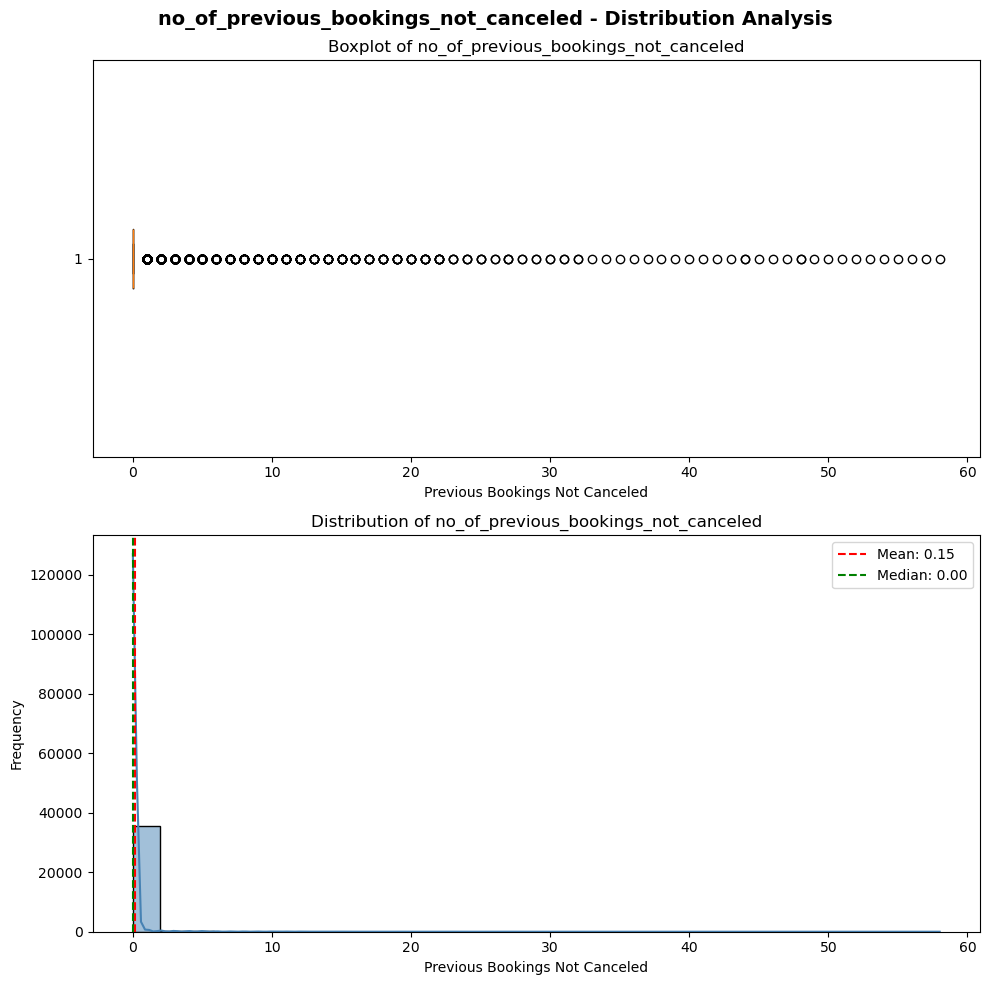

In [60]:
plot_distribution(df, 'no_of_previous_bookings_not_canceled', xlabel='Previous Bookings Not Canceled')

In [61]:
describe_distribution(df, 'no_of_previous_bookings_not_canceled')

Lower Outlier Fence = 0.0
Upper Outlier Fence = 0.0
Outlier count: 808
Skewness:  19.23767650068215
The distribution is highly skewed to the right.


count   36197.00
mean        0.15
std         1.76
min         0.00
25%         0.00
50%         0.00
75%         0.00
max        58.00
Name: no_of_previous_bookings_not_canceled, dtype: float64

In [62]:
#Show most common (highest) values for previous cancellations
df['no_of_previous_bookings_not_canceled'].value_counts().loc[lambda x: x > 50]

no_of_previous_bookings_not_canceled
0    35389
1      226
2      112
3       79
4       65
5       59
Name: count, dtype: int64

#### Previous Bookings Not Canceled Observations:
- ~98% of the bookings in this dataset have no previous bookings that were not canceled.  This coupled with the above data implies that many customers are first time customers.

#### Create and Check Total Previous Bookings

In [63]:
#Create a column for total number of previous bookings
df['total_previous_bookings'] = (df['no_of_previous_cancellations']+ df['no_of_previous_bookings_not_canceled'])
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_nights,total_previous_bookings
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled,3,0
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled,5,0
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled,3,0
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled,2,0
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled,2,0


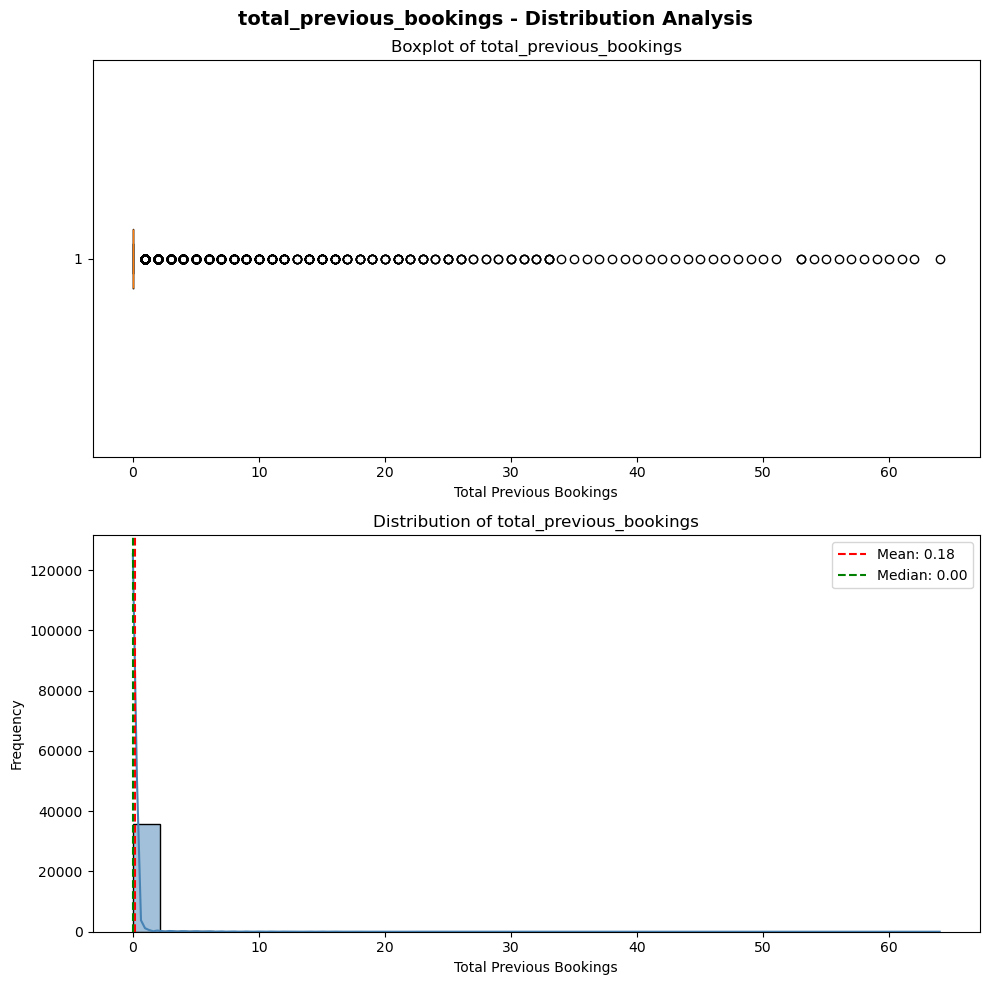

In [64]:
plot_distribution(df, 'total_previous_bookings', xlabel='Total Previous Bookings')

In [65]:
describe_distribution(df, 'total_previous_bookings')

Lower Outlier Fence = 0.0
Upper Outlier Fence = 0.0
Outlier count: 926
Skewness:  18.552795373862786
The distribution is highly skewed to the right.


count   36197.00
mean        0.18
std         1.96
min         0.00
25%         0.00
50%         0.00
75%         0.00
max        64.00
Name: total_previous_bookings, dtype: float64

In [66]:
#Show most common (highest) values for total previous bookings
df['total_previous_bookings'].value_counts().loc[lambda x: x > 50]

total_previous_bookings
0    35271
1      320
2      113
3       77
4       60
Name: count, dtype: int64

#### Total Previous Bookings Observations:
- Total previous bookings range from 0 to 64.
- This data confirms the vast majority of bookings are from new customers with no previous booking history (~97%)

#### Create and Check Cancellation Rate

In [67]:
#Create a column for cancellation rate (previous cancellations)/(Total Previous Bookings)
#Set rate to 0 where total previous bookings is 0
df['cancellation_rate'] = np.where(
    df['total_previous_bookings'] > 0,
    df['no_of_previous_cancellations'] / df['total_previous_bookings'],
    0
)
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_nights,total_previous_bookings,cancellation_rate
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled,3,0,0.00
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled,5,0,0.00
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled,3,0,0.00
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled,2,0,0.00
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled,2,0,0.00


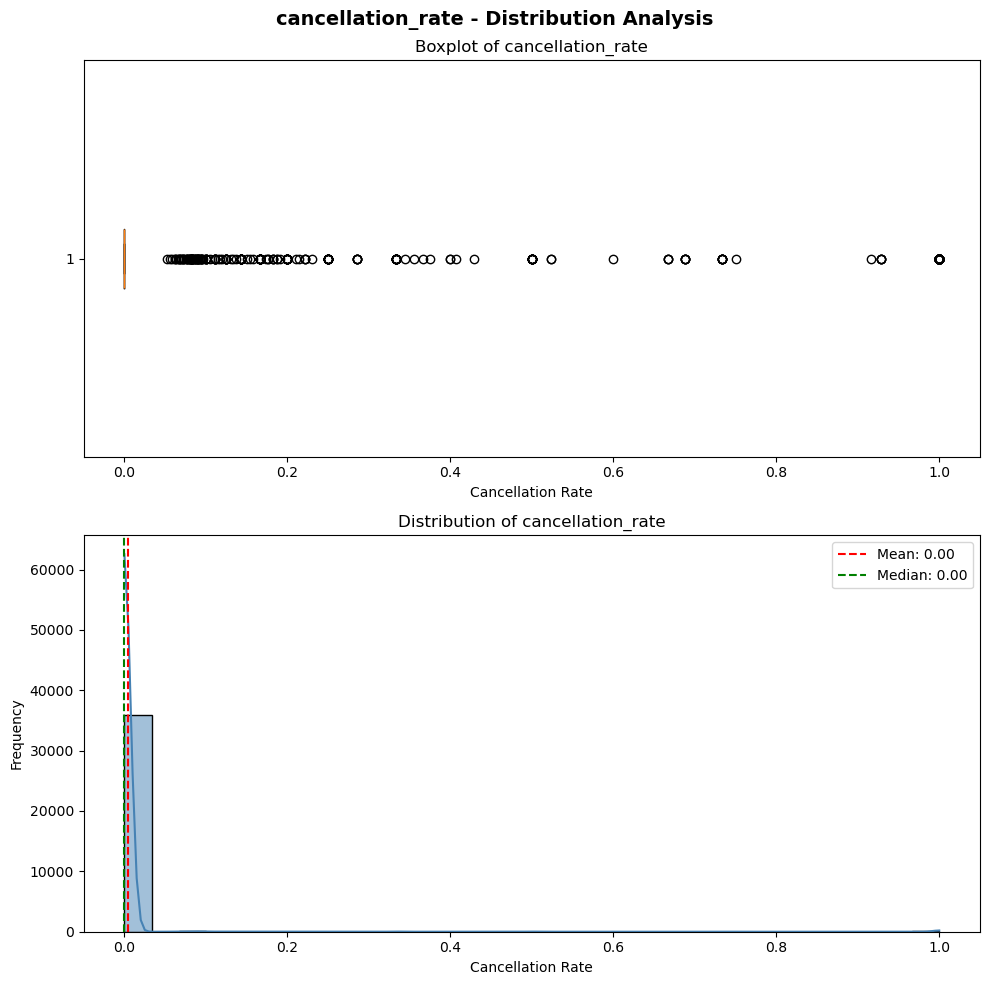

In [68]:
plot_distribution(df, 'cancellation_rate', xlabel='Cancellation Rate')

In [69]:
describe_distribution(df, 'cancellation_rate')

Lower Outlier Fence = 0.0
Upper Outlier Fence = 0.0
Outlier count: 337
Skewness:  14.84112563411896
The distribution is highly skewed to the right.


count   36197.00
mean        0.00
std         0.06
min         0.00
25%         0.00
50%         0.00
75%         0.00
max         1.00
Name: cancellation_rate, dtype: float64

In [70]:
print('There are ', (df['cancellation_rate'] > 0).sum(), ' bookings (',  ((((df['cancellation_rate'] > 0).sum()/df.shape[0]))*100).round(2), '%) with a cancellation rate') 

There are  337  bookings ( 0.93 %) with a cancellation rate


This matches the count of cancellations above.

#### Cancellation Rate Observations:
- As expected with majority new customers, there is a very small subset of the population with a previous cancellation rate.
- While everyone with a cancellation rate is an outlier, these are important and legitimate datapoints and will not be imputed.

#### Average Price Per Room

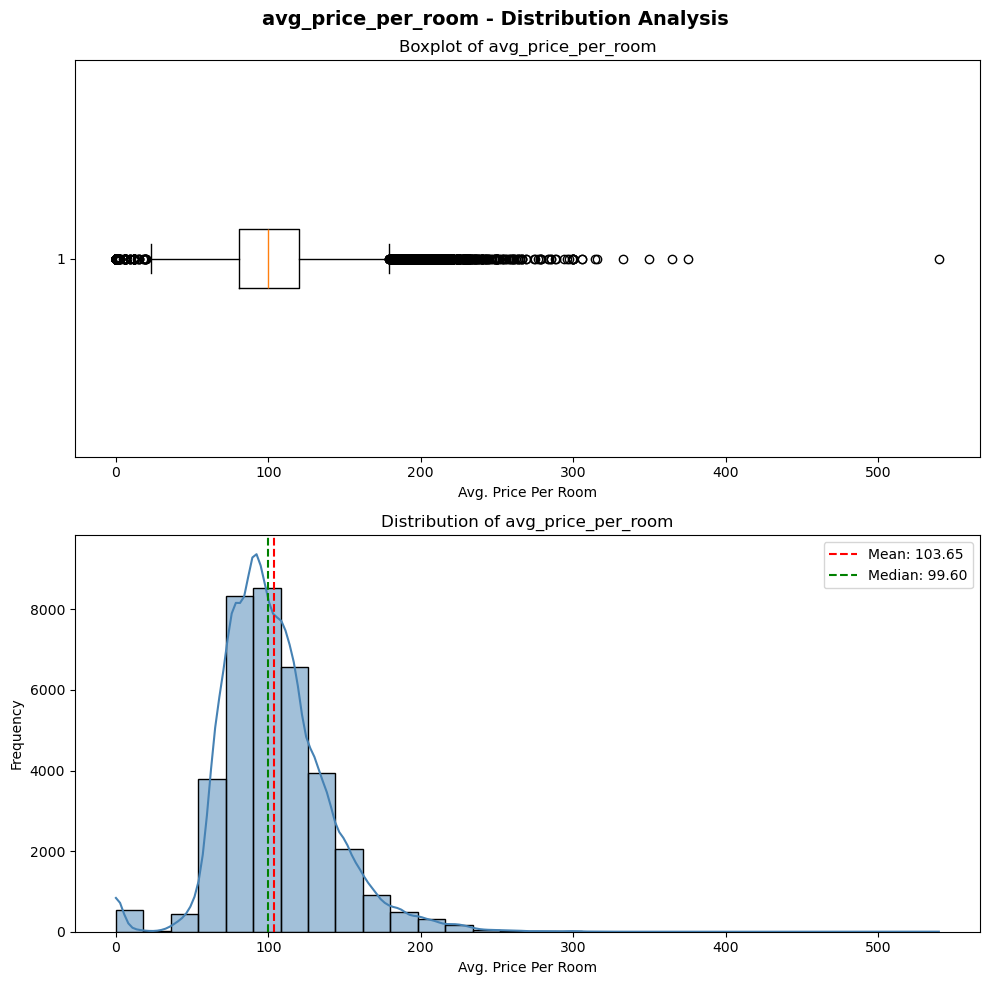

In [71]:
plot_distribution(df, 'avg_price_per_room', xlabel='Avg. Price Per Room')

In [72]:
describe_distribution(df, 'avg_price_per_room')

Lower Outlier Fence = 21.694999999999993
Upper Outlier Fence = 179.175
Outlier count: 1622
Skewness:  0.7229453359438027
The distribution is moderately skewed to the right.


count   36197.00
mean      103.65
std        34.80
min         0.00
25%        80.75
50%        99.60
75%       120.12
max       540.00
Name: avg_price_per_room, dtype: float64

Outliers to the right do not concern me as 540 is not an unheard of price for a nice hotel.  What concerns me are the 0 values.

In [73]:
#Check 0 values in avg_price_per_room
print('There are', (df['avg_price_per_room']==0).sum(), 'bookings showing 0 average price per room')

There are 467 bookings showing 0 average price per room


I noted above that there are some rooms marked Complementary under Market Segment.  Let's see how these match up with our 0 bookings.

In [74]:
#Check 0 against Complementary
print('There are',
      ((df['avg_price_per_room'] == 0) & (df['market_segment_type'] == 'Complementary')).sum(),
        'bookings where price is 0 and market segment is Complementary, or',
        ((((df['avg_price_per_room'] == 0) & (df['market_segment_type'] == 'Complementary')).sum()/(df['avg_price_per_room']==0).sum())*100).round(2),
      '%'
     )

There are 341 bookings where price is 0 and market segment is Complementary, or 73.02 %


In [75]:
#Looking at the 0 Bookings that do not show as complementary
df[
    (df['avg_price_per_room'] == 0)
    &
    (df['market_segment_type'] != 'Complementary')
].head(10)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_nights,total_previous_bookings,cancellation_rate
1046,1,0,0,2,Meal Plan 2,0,Room_Type 1,6,2017,12,10,Online,0,0,0,0.00,0,Not_Canceled,2,0,0.00
1176,1,0,0,2,Meal Plan 2,0,Room_Type 1,6,2017,12,10,Online,0,0,0,0.00,0,Not_Canceled,2,0,0.00
1401,1,0,0,2,Meal Plan 2,0,Room_Type 1,6,2017,12,10,Online,0,0,0,0.00,0,Not_Canceled,2,0,0.00
2749,1,0,0,1,Meal Plan 1,0,Room_Type 1,5,2017,10,21,Online,0,0,0,0.00,0,Not_Canceled,1,0,0.00
2780,1,0,0,1,Meal Plan 1,0,Room_Type 1,289,2017,10,17,Online,0,0,0,0.00,0,Canceled,1,0,0.00
3023,1,0,0,2,Meal Plan 2,0,Room_Type 1,6,2017,12,10,Online,0,0,0,0.00,0,Not_Canceled,2,0,0.00
3104,1,0,0,2,Meal Plan 1,0,Room_Type 1,32,2017,11,20,Online,0,0,0,0.00,0,Not_Canceled,2,0,0.00
3570,1,0,0,2,Meal Plan 2,0,Room_Type 1,14,2017,9,17,Online,0,0,0,0.00,0,Not_Canceled,2,0,0.00
4610,2,0,0,1,Meal Plan 1,0,Room_Type 1,5,2017,10,21,Online,0,0,0,0.00,0,Not_Canceled,1,0,0.00
5345,1,0,0,2,Meal Plan 2,0,Room_Type 1,6,2017,12,10,Online,0,0,0,0.00,0,Not_Canceled,2,0,0.00


Nothing jumps out as peculiar across these bookings.  It would appear there are 126 bookings that were not complementary, but show up as 0 average price per room.

In [76]:
#Checking further these not-complementary 0 rooms against cancellations
(
    (df['avg_price_per_room'] == 0)
    &
    (df['market_segment_type'] != 'Complementary')
    &
    (df['booking_status'] == 'Canceled')
).sum()

np.int64(4)

#### Average Price per Room Observations:
- Overall the average price per room is 103.65.
- The outliers to the right are legitimate data points and will not be treated.
- The stand out here are the 126 bookings that show 0 average price per room and do not show a 'Complementary' status.  However, since only one market segment shows, these may represent complementary rooms that overlapped with another market segment and only one of the segments is showing.  In the real world I would confirm this assumption with INNHotels.  For the purposes of this project I will assume these 0 values to be valid since this data does include Complementary bookings.

#### Number of special requests

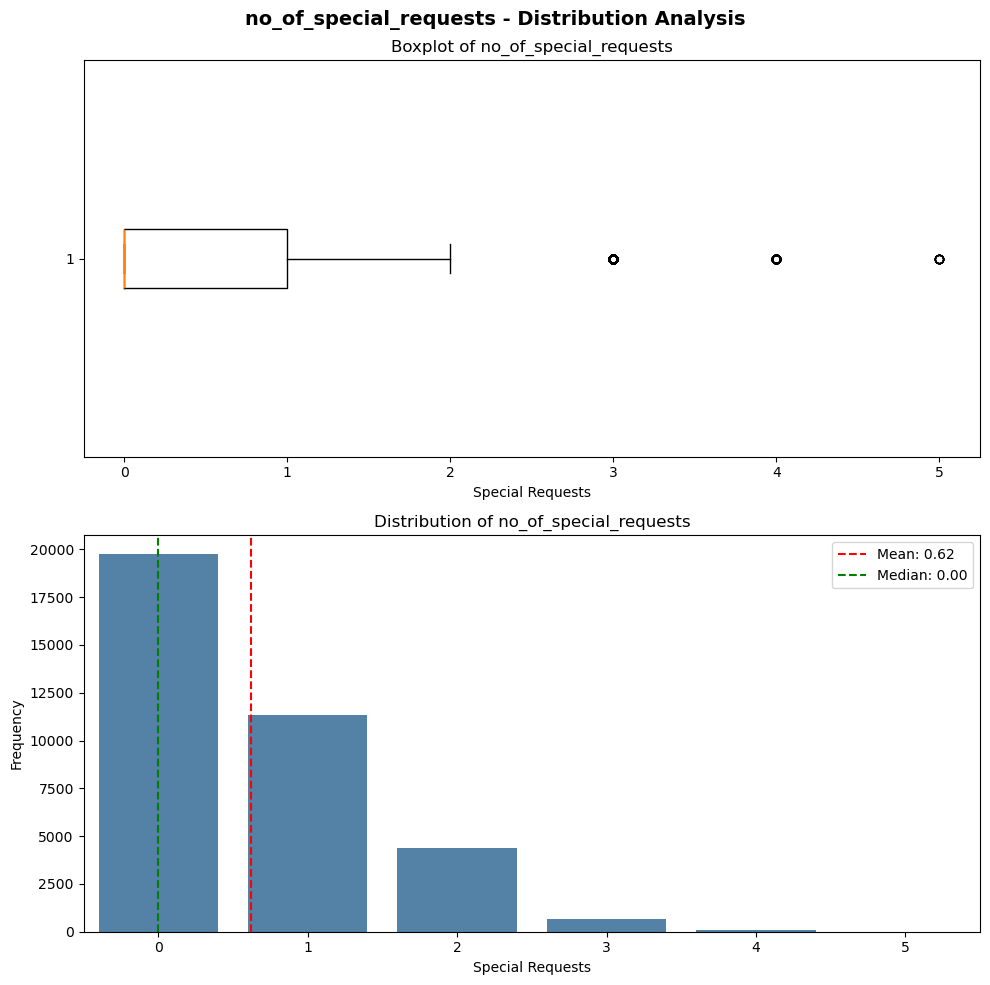

In [77]:
plot_box_count(df, 'no_of_special_requests', xlabel='Special Requests')

In [78]:
describe_distribution(df, 'no_of_special_requests')

Lower Outlier Fence = -1.5
Upper Outlier Fence = 2.5
Outlier count: 760
Skewness:  1.1459221034886744
The distribution is highly skewed to the right.


count   36197.00
mean        0.62
std         0.79
min         0.00
25%         0.00
50%         0.00
75%         1.00
max         5.00
Name: no_of_special_requests, dtype: float64

#### Special Request Observations:
- Special Requests range from 0 to 5 with 0 being the most common.
- Outliers represent legitimate data and will not be treated.

#### Booking Status

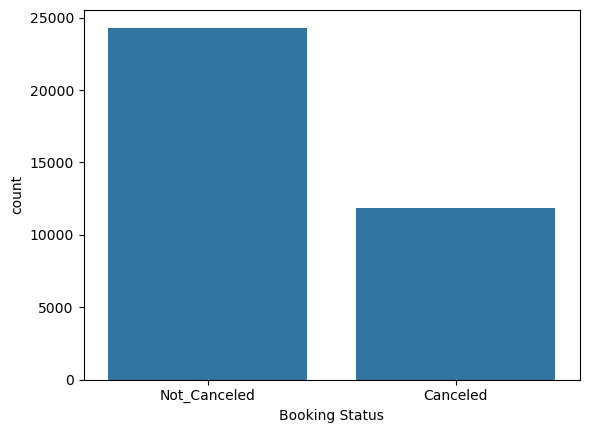

In [79]:
sns.countplot(df, x='booking_status')
plt.xlabel('Booking Status')
plt.show()

In [80]:
df['booking_status'].value_counts()

booking_status
Not_Canceled    24314
Canceled        11883
Name: count, dtype: int64

In [81]:
df['booking_status'].value_counts()/df.shape[0]

booking_status
Not_Canceled   0.67
Canceled       0.33
Name: count, dtype: float64

#### Booking Status Observations:
- ~33% of the bookings in this dataset were canceled. (Leading Question 4 Answer)

#### A Note on Columns Created:
- The columns created will certainly lead to multicollinearity later, so these columns will be removed following EDA. Still, I feel it was important to create these in order to fully examine what drives cancellation prediction - (ie, is it the presence of a previous cancellation, or the rate of cancellation in the past?  does week v. weekend matter most or total nights on the booking?)

### Multivariate EDA

#### Verify Date Range Covered

In [82]:
df.loc[df['arrival_year'] == 2017, 'arrival_month'].value_counts()

arrival_month
10    1904
9     1645
8     1013
12     922
11     644
7      363
Name: count, dtype: int64

In [83]:
df.loc[df['arrival_year'] == 2018, 'arrival_month'].value_counts()

arrival_month
10    3398
6     3197
9     2958
8     2797
4     2731
5     2595
7     2553
3     2356
11    2327
12    2090
2     1695
1     1009
Name: count, dtype: int64

#### Date Range Observations:
- We see now that only bookings for the second half of 2017 were captured in this dataset, while all of 2018 was captured.  This is significant as it makes the year 2017 less reliable as a predictor since only half of the year's data is represented and we saw above, bookings across months are not generally even.

#### Heat Map

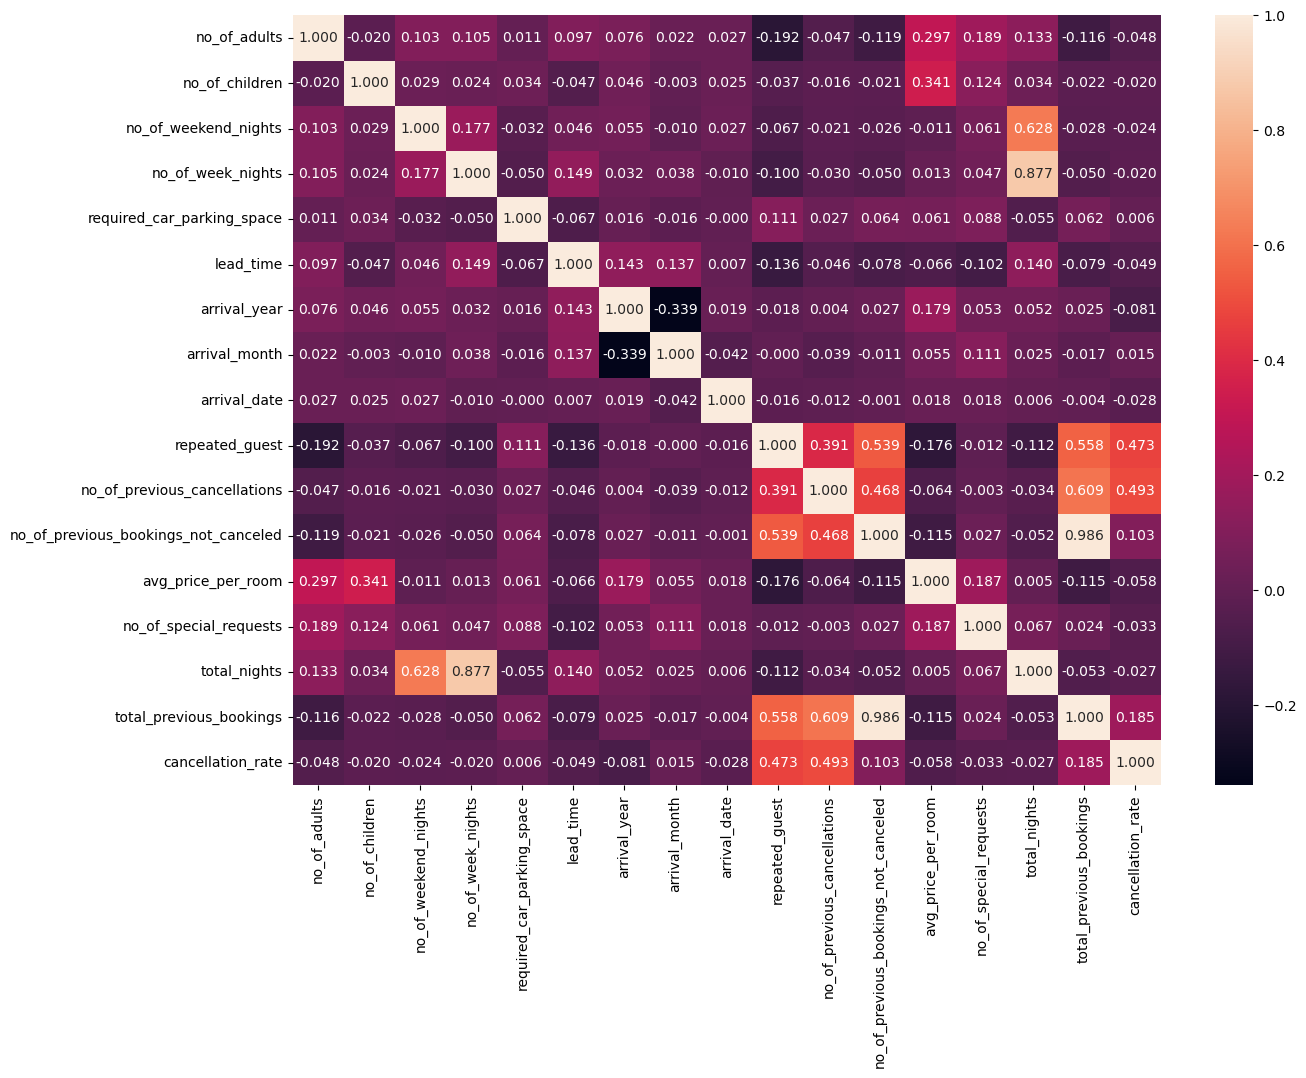

In [84]:
# Heatmap of numeric values
plt.figure(figsize=(14, 10))
sns.heatmap(
    data = df.select_dtypes(include='number').corr(), 
    annot=True,
    fmt='.3f'
)
plt.show()

In [85]:
#Filter to moderate to strong correlations (>.3)
find_correlations(df,.4)

no_of_previous_bookings_not_canceled  total_previous_bookings                0.99
no_of_week_nights                     total_nights                           0.88
no_of_weekend_nights                  total_nights                           0.63
no_of_previous_cancellations          total_previous_bookings                0.61
repeated_guest                        total_previous_bookings                0.56
                                      no_of_previous_bookings_not_canceled   0.54
no_of_previous_cancellations          cancellation_rate                      0.49
repeated_guest                        cancellation_rate                      0.47
no_of_previous_cancellations          no_of_previous_bookings_not_canceled   0.47
dtype: float64

#### Heatmap Observations:
There is nothing too surprising in these results.
- The number of previous bookings not canceled is strongly correlated with the total number of previous bookings.
- Number of week nights and weekend nights both strongly correlate with total nights.
- Number of previous cancellations has a fairly strong correlation with number of total previous bookings.
- One would expect some correlation between number of previous cancellations and cancellation rate.
- There is a moderate correlation between previous cancellations and bookings not canceled which can be expected as more total bookings come with more opportunities for cancellation need.

Now let's look at some of the Object data types not captured in the heatmap

#### Meal Plan

##### Meal Plan vs. Nights Booked

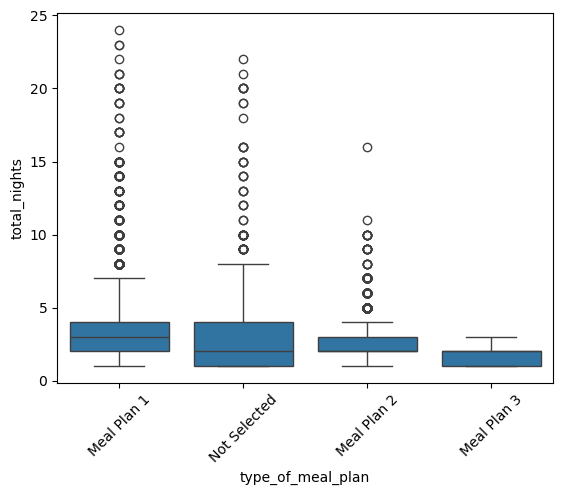

In [86]:
#Meal Plan Selection vs. total nights
sns.boxplot(
    data=df,
    x='type_of_meal_plan',
    y='total_nights'
)

plt.xticks(rotation=45)
plt.show()

In [87]:
#Mean total nights booked by meal plan
df.groupby('type_of_meal_plan')['total_nights'].mean()

type_of_meal_plan
Meal Plan 1    3.11
Meal Plan 2    2.70
Meal Plan 3    1.80
Not Selected   2.74
Name: total_nights, dtype: float64

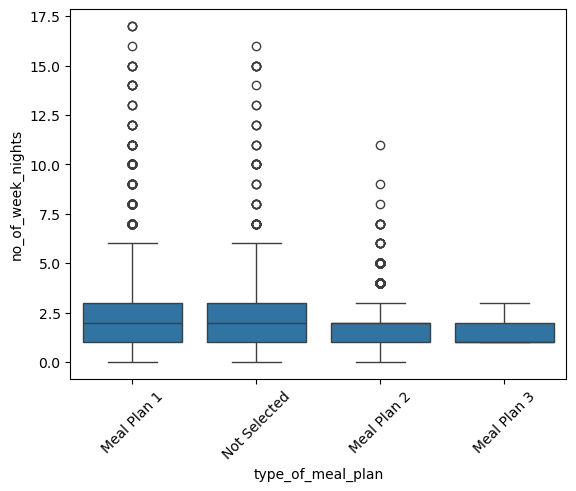

In [88]:
#Meal Plan Selection vs. number of week nights
sns.boxplot(
    data=df,
    x='type_of_meal_plan',
    y='no_of_week_nights'
)

plt.xticks(rotation=45)
plt.show()

In [89]:
#Mean week nights booked by meal plan
df.groupby('type_of_meal_plan')['no_of_week_nights'].mean()

type_of_meal_plan
Meal Plan 1    2.28
Meal Plan 2    2.02
Meal Plan 3    1.60
Not Selected   1.96
Name: no_of_week_nights, dtype: float64

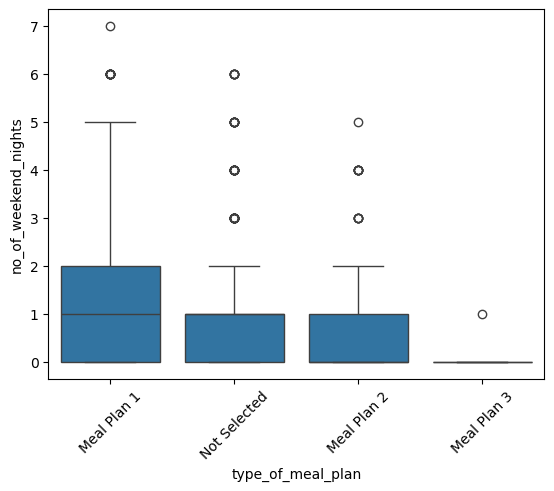

In [90]:
#Meal Plan Selection vs. number of weekend nights
sns.boxplot(
    data=df,
    x='type_of_meal_plan',
    y='no_of_weekend_nights'
)

plt.xticks(rotation=45)
plt.show()

In [91]:
#Mean weekend nights booked by meal plan
df.groupby('type_of_meal_plan')['no_of_weekend_nights'].mean()

type_of_meal_plan
Meal Plan 1    0.83
Meal Plan 2    0.68
Meal Plan 3    0.20
Not Selected   0.78
Name: no_of_weekend_nights, dtype: float64

##### Meal Plan and Room Type

In [92]:
#Meal Plan Selection vs. Room Type Normalized
pd.crosstab(
    df['type_of_meal_plan'],
    df['room_type_reserved'],
    normalize='index'
)

room_type_reserved,Room_Type 1,Room_Type 2,Room_Type 3,Room_Type 4,Room_Type 5,Room_Type 6,Room_Type 7
type_of_meal_plan,,,,,,,
Meal Plan 1,0.72,0.02,0.00,0.21,0.01,0.03,0.01
Meal Plan 2,0.89,0.00,0.00,0.08,0.00,0.02,0.00
Meal Plan 3,0.20,0.00,0.00,0.20,0.00,0.00,0.60
Not Selected,0.98,0.00,0.00,0.01,0.00,0.00,0.00


##### Meal Plan by Month

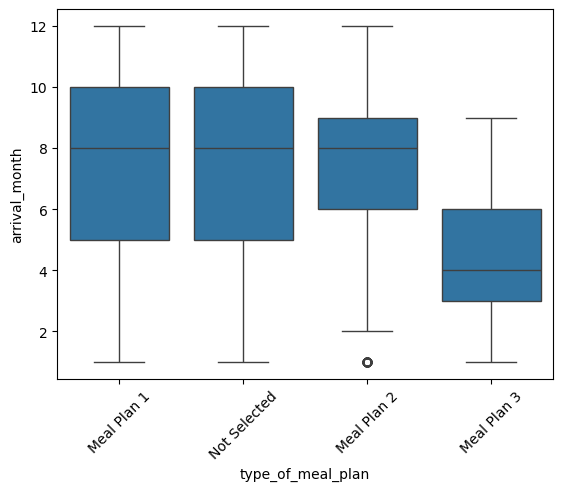

In [93]:
#Meal Plan Selection vs. Month
sns.boxplot(
    data=df,
    x='type_of_meal_plan',
    y='arrival_month'
)

plt.xticks(rotation=45)
plt.show()

##### Meal plan by segment

In [94]:
#Meal Plan v. Segment
pd.crosstab(
    df['type_of_meal_plan'],
    df['market_segment_type'],
    normalize='index'
)

market_segment_type,Aviation,Complementary,Corporate,Offline,Online
type_of_meal_plan,,,,,
Meal Plan 1,0.00,0.01,0.07,0.29,0.62
Meal Plan 2,0.00,0.00,0.00,0.72,0.28
Meal Plan 3,0.00,0.80,0.00,0.20,0.00
Not Selected,0.00,0.00,0.00,0.03,0.96


##### Meal Plan vs Price Per Room

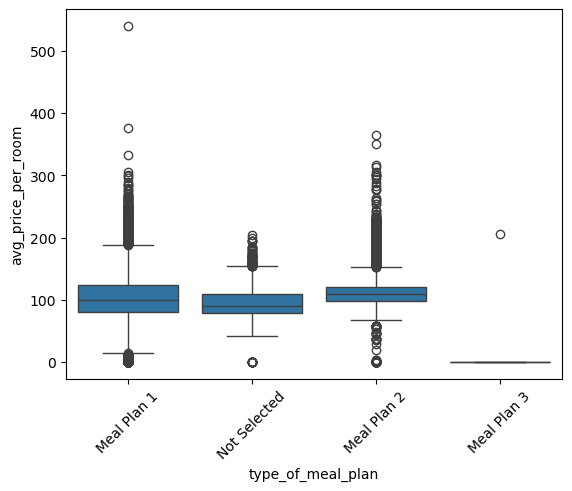

In [95]:
#Meal Plan Selection vs. Price per room
sns.boxplot(
    data=df,
    x='type_of_meal_plan',
    y='avg_price_per_room'
)

plt.xticks(rotation=45)
plt.show()

##### Meal Plan and Status

In [96]:
#Meal Plan v. Status
pd.crosstab(
    df['type_of_meal_plan'],
    df['booking_status'],
    normalize='index'
)

booking_status,Canceled,Not_Canceled
type_of_meal_plan,,
Meal Plan 1,0.31,0.69
Meal Plan 2,0.46,0.54
Meal Plan 3,0.20,0.80
Not Selected,0.33,0.67


##### Meal Plan Observations: 
- Meal Plan 1 appears to be the most likely selection for longer stays.
- Meal Plan 3 is most associated with Room Type 7 while all the others are most associated with room 1.
- Meal plan selection seems pretty even across the year skewed slightly toward the more popular months for bookings, except for meal plan 3 which is more popular early in the year.
- Meal Plan 1 and no meal plan are most booked online. Meal plan 2 is most booked offline. Meal plan 3 is most booked with complementary stays. This aligns with the above observation as Complementary stays are likely offered in the less popular off months.
- Meal Plan 3 also has the lowest associated price per room, likely due to the fact that it is mostly associated with Complementary bookings.
- The meal plan with the highest cancellation rate is Meal Plan 2 with 46% of bookings canceled.

#### Room Type

##### Room Type and Age Group

In [97]:
#Room Type v. Adults
pd.crosstab(
    df['room_type_reserved'],
    df['no_of_adults'],
)

no_of_adults,0,1,2,3,4
room_type_reserved,,,,,
Room_Type 1,3,6910,20672,481,0
Room_Type 2,133,25,531,1,0
Room_Type 3,0,3,4,0,0
Room_Type 4,0,571,3740,1736,1
Room_Type 5,0,100,135,29,1
Room_Type 6,2,42,880,39,1
Room_Type 7,1,14,99,30,13


In [98]:
#Room Type v. Children
pd.crosstab(
    df['room_type_reserved'],
    df['no_of_children'],
)

no_of_children,0,1,2,3,9,10
room_type_reserved,,,,,,
Room_Type 1,26722,1308,34,1,1,0
Room_Type 2,481,24,179,5,1,0
Room_Type 3,7,0,0,0,0,0
Room_Type 4,5842,190,15,0,0,1
Room_Type 5,241,13,11,0,0,0
Room_Type 6,121,64,774,5,0,0
Room_Type 7,90,16,43,8,0,0


##### Room Type v Lead Time

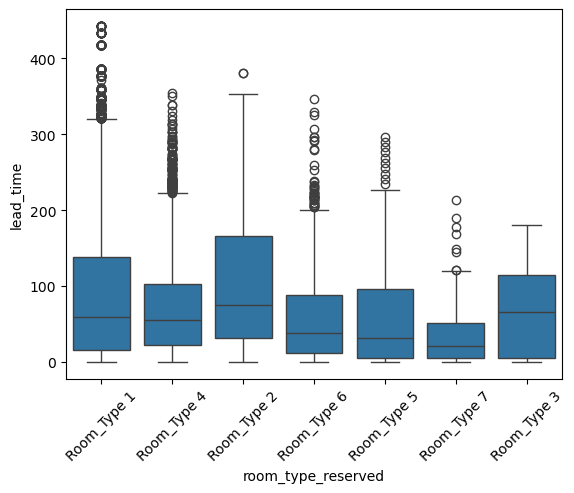

In [99]:
#Room Type vs. Lead Time
sns.boxplot(
    data=df,
    x='room_type_reserved',
    y='lead_time'
)

plt.xticks(rotation=45)
plt.show()

In [100]:
#Display means
df.groupby('room_type_reserved')['lead_time'].mean()

room_type_reserved
Room_Type 1    89.73
Room_Type 2   101.04
Room_Type 3    69.57
Room_Type 4    69.27
Room_Type 5    59.55
Room_Type 6    61.08
Room_Type 7    37.29
Name: lead_time, dtype: float64

##### Room Type and Segment

In [101]:
#Room Type v. Segment
pd.crosstab(
    df['room_type_reserved'],
    df['market_segment_type'],
)

market_segment_type,Aviation,Complementary,Corporate,Offline,Online
room_type_reserved,,,,,
Room_Type 1,60,238,1833,9747,16188
Room_Type 2,0,19,2,57,612
Room_Type 3,0,2,1,2,2
Room_Type 4,65,49,99,613,5222
Room_Type 5,0,17,74,81,93
Room_Type 6,0,14,3,23,924
Room_Type 7,0,39,5,5,108


##### Room Type v Price

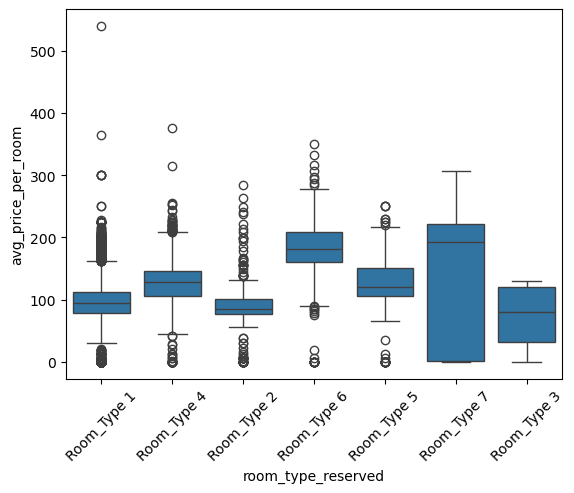

In [102]:
#Room Type vs. Price
sns.boxplot(
    data=df,
    x='room_type_reserved',
    y='avg_price_per_room'
)

plt.xticks(rotation=45)
plt.show()

In [103]:
#Display means
df.groupby('room_type_reserved')['avg_price_per_room'].mean()

room_type_reserved
Room_Type 1    96.14
Room_Type 2    88.10
Room_Type 3    73.68
Room_Type 4   125.47
Room_Type 5   123.73
Room_Type 6   182.59
Room_Type 7   156.19
Name: avg_price_per_room, dtype: float64

##### Room Type v Booking Status

In [104]:
#Room Type v. Booking Status
pd.crosstab(
    df['room_type_reserved'],
    df['booking_status'],
    normalize='index'
)

booking_status,Canceled,Not_Canceled
room_type_reserved,,
Room_Type 1,0.32,0.68
Room_Type 2,0.33,0.67
Room_Type 3,0.29,0.71
Room_Type 4,0.34,0.66
Room_Type 5,0.27,0.73
Room_Type 6,0.42,0.58
Room_Type 7,0.23,0.77


##### Room Type Observations:
- Rooms Types 4-7 are likely larger rooms as they are the only rooms with > 3 adults booked
- Room Type 2 is most popular for bookings with 0 adults.
- For 1 child Room type 1 is most popular, for 2 children room type 6 is most popular.
- Room Type 2 has the longest average lead time at booking
- All room types are most often booked online except room type 3 which is equally booked offline and as complementary.
- Room types 4-7 appear to be of a higher price tier than Room types 1-3.
- Room Type 6 has the highest cancellation rate at 42%

#### Segment

##### Segment by Age Group

In [105]:
#Segment v. Adults
pd.crosstab(
    df['market_segment_type'],
    df['no_of_adults'],
    normalize='index'
)

no_of_adults,0,1,2,3,4
market_segment_type,,,,,
Aviation,0.00,0.98,0.02,0.00,0.00
Complementary,0.01,0.50,0.48,0.01,0.00
Corporate,0.00,0.78,0.22,0.01,0.00
Offline,0.00,0.25,0.72,0.03,0.00
Online,0.01,0.14,0.77,0.09,0.00


In [106]:
#Segment v. Children
pd.crosstab(
    df['market_segment_type'],
    df['no_of_children'],
    normalize='index'
)

no_of_children,0,1,2,3,9,10
market_segment_type,,,,,,
Aviation,1.00,0.00,0.00,0.00,0.00,0.00
Complementary,0.92,0.05,0.03,0.01,0.00,0.00
Corporate,1.00,0.00,0.00,0.00,0.00,0.00
Offline,0.98,0.02,0.00,0.00,0.00,0.00
Online,0.89,0.06,0.04,0.00,0.00,0.00


##### Segment v Lead Time

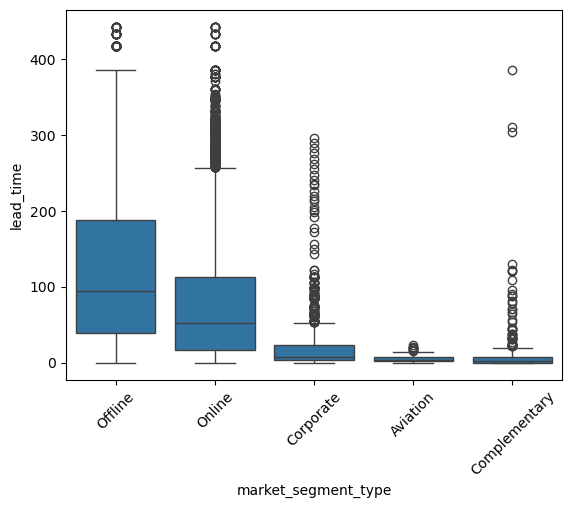

In [107]:
#Segment v. Lead Time
sns.boxplot(
    data=df,
    x='market_segment_type',
    y='lead_time'
)

plt.xticks(rotation=45)
plt.show()

In [108]:
#Display means
df.groupby('market_segment_type')['lead_time'].mean()

market_segment_type
Aviation          5.49
Complementary    11.69
Corporate        21.82
Offline         122.87
Online           75.40
Name: lead_time, dtype: float64

##### Segment v Price

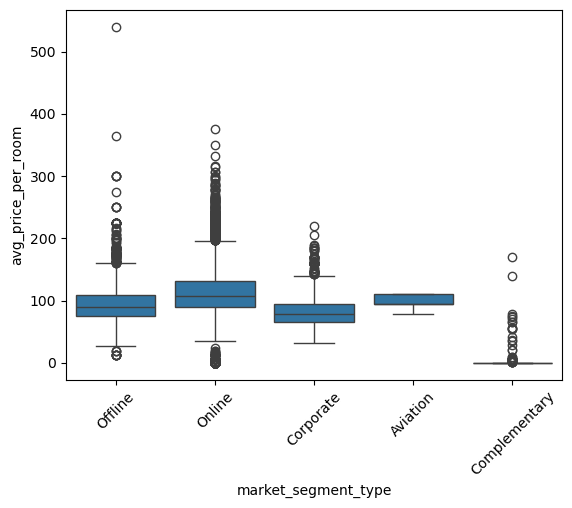

In [109]:
#Segment v. Price
sns.boxplot(
    data=df,
    x='market_segment_type',
    y='avg_price_per_room'
)

plt.xticks(rotation=45)
plt.show()

In [110]:
#Display means
df.groupby('market_segment_type')['avg_price_per_room'].mean()

market_segment_type
Aviation        100.70
Complementary     3.25
Corporate        82.91
Offline          91.63
Online          112.57
Name: avg_price_per_room, dtype: float64

##### Segment v Special Requests

In [111]:
#Segment v. Special Requests
pd.crosstab(
    df['market_segment_type'],
    df['no_of_special_requests'],
    normalize='index'
)

no_of_special_requests,0,1,2,3,4,5
market_segment_type,,,,,,
Aviation,1.00,0.00,0.00,0.00,0.00,0.00
Complementary,0.43,0.36,0.13,0.05,0.03,0.00
Corporate,0.80,0.18,0.01,0.00,0.00,0.00
Offline,0.82,0.16,0.02,0.00,0.00,0.00
Online,0.40,0.39,0.18,0.03,0.00,0.00


##### Segment v Booking Status

In [112]:
#Segment v. Booking Status
pd.crosstab(
    df['market_segment_type'],
    df['booking_status'],
    normalize='index'
)

booking_status,Canceled,Not_Canceled
market_segment_type,,
Aviation,0.30,0.70
Complementary,0.00,1.00
Corporate,0.11,0.89
Offline,0.30,0.70
Online,0.37,0.63


##### Segment Observations:
- Not surprisingly, professional segments most commonly book for 1 adult and standard offline and online bookings for 2 adults. Complementary bookings are fairly equally split between 1 and 2 adults.
- Offline bookings have the longest lead time.
- Standard online bookings cost the most per room on average.  It appears industry (corporate and aviation) may get a small discount.   Offline bookings are notably less expensive per room than online, likely due to the fact that they tend to be booked farther in advance. (Leading Question 3 Answer)
- Online booking and Complementary stays come with a higher rate of special requests.
- Online bookings have the highest rate of cancellation at 37% followed by Aviation and Offline at 30%.

#### Booking Status

##### Status v Nights Booked

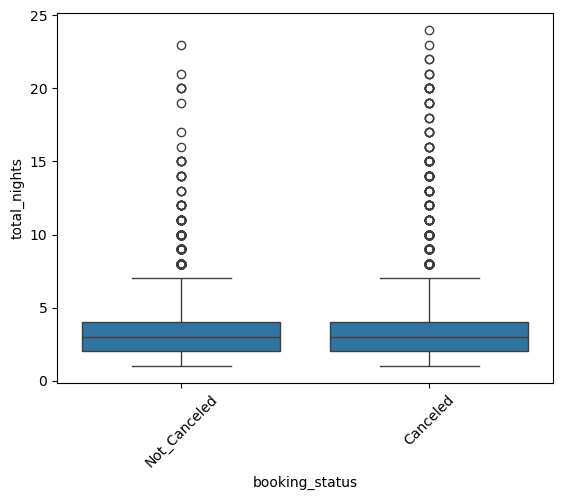

In [113]:
#Status vs. total nights
sns.boxplot(
    data=df,
    x='booking_status',
    y='total_nights'
)

plt.xticks(rotation=45)
plt.show()

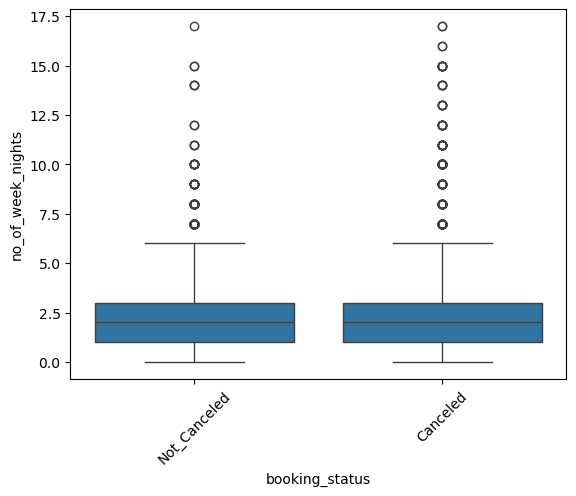

In [114]:
#Status vs. week nights
sns.boxplot(
    data=df,
    x='booking_status',
    y='no_of_week_nights'
)

plt.xticks(rotation=45)
plt.show()

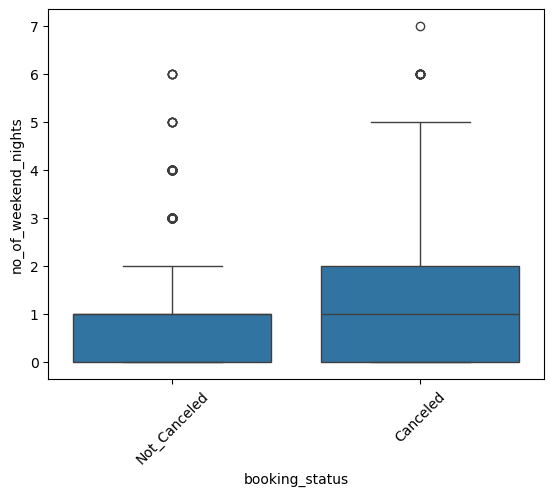

In [115]:
#Status vs. weekend nights
sns.boxplot(
    data=df,
    x='booking_status',
    y='no_of_weekend_nights'
)

plt.xticks(rotation=45)
plt.show()

##### Status v Lead Time

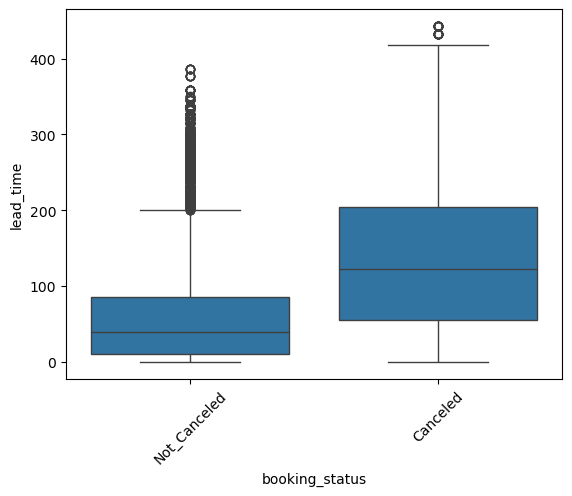

In [116]:
#Status vs. Lead Time
sns.boxplot(
    data=df,
    x='booking_status',
    y='lead_time'
)

plt.xticks(rotation=45)
plt.show()

In [117]:
#Display means
df.groupby('booking_status')['lead_time'].mean()

booking_status
Canceled       139.20
Not_Canceled    58.98
Name: lead_time, dtype: float64

##### Status by Month

In [118]:
#Arrival Month v. Booking Status
pd.crosstab(
    df['arrival_month'],
    df['booking_status'],
    normalize='index'
)

booking_status,Canceled,Not_Canceled
arrival_month,,
1,0.02,0.98
2,0.25,0.75
3,0.30,0.70
4,0.36,0.64
5,0.37,0.63
6,0.40,0.60
7,0.45,0.55
8,0.39,0.61
9,0.33,0.67


##### Status v Repeat Guest

In [119]:
#Repeated Guest v. Booking Status
pd.crosstab(
    df['repeated_guest'],
    df['booking_status'],
    normalize='index'
)

booking_status,Canceled,Not_Canceled
repeated_guest,,
0,0.34,0.66
1,0.02,0.98


##### Status v Price

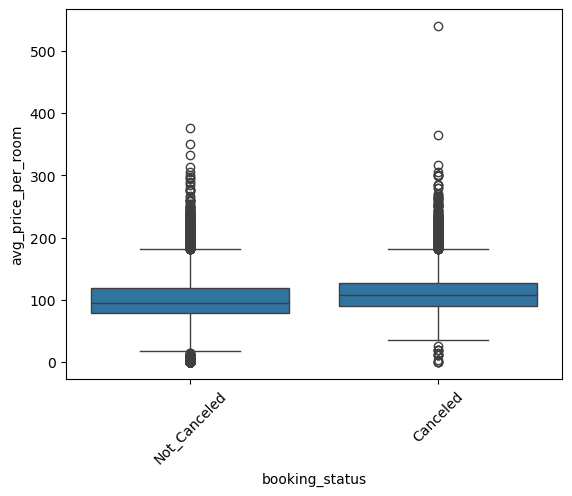

In [120]:
#Status vs. Price
sns.boxplot(
    data=df,
    x='booking_status',
    y='avg_price_per_room'
)

plt.xticks(rotation=45)
plt.show()

In [121]:
#Display means
df.groupby('booking_status')['avg_price_per_room'].mean()

booking_status
Canceled       110.61
Not_Canceled   100.24
Name: avg_price_per_room, dtype: float64

##### Status and Special Requests

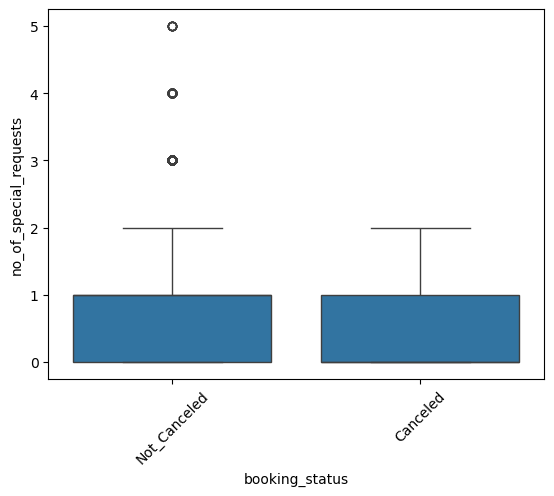

In [122]:
#Status vs. Special Requests
sns.boxplot(
    data=df,
    x='booking_status',
    y='no_of_special_requests'
)

plt.xticks(rotation=45)
plt.show()

In [123]:
#Display means
df.groupby('booking_status')['no_of_special_requests'].mean()

booking_status
Canceled       0.33
Not_Canceled   0.76
Name: no_of_special_requests, dtype: float64

In [124]:
print('There are',
      ((df['no_of_special_requests'] > 2) & (df['booking_status'] == 'Not_Canceled')).sum(),
      'bookings not canceled with > 2 special requests which accounts for',
      (((((df['no_of_special_requests'] > 2) & (df['booking_status'] == 'Not_Canceled')).sum())/df.shape[0])*100).round(2),
      '% of the data'
     )

There are 760 bookings not canceled with > 2 special requests which accounts for 2.1 % of the data


##### Status Observations:
- Canceled vs. Not Canceled look fairly similar across stay durations.
- Canceled bookings are associated with a much higher average lead time.
- July has the highest cancellation rate at 45%.
- 34% of new guests canceled while only 2% of repeat guests canceled. (Leading Question 5 Answer)
- Price data is fairly similar for canceled and not canceled bookings.
- Outliers with 3 or more special requests appear to be less prone to cancellation, but otherwise the data for cancellation by number of requests is fairly similar.  These outliers are also not a large enough set (2% of the data) to draw reliable conclusions from.  (Leading Question 6 Answer)

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

#### Data Preprocessing Notes
- I have already dropped Booking_ID
- Outliers have been addressed above in EDA
- 78 rows were removed for reflecting 0 night stays which does not align with Hotel business standards and were very likely erroneous entries representing a tiny proportion of data.
- Columns Created: total_nights, total_previous_bookings, and cancellation_rate
- Since cancellation_rate, total_nights, and total_previous_bookings were created as linear combinations of existing columns, I will drop them here.  They were useful for EDA, but will not be for our modeling.
- I will also drop arrival_year.  As noted above only half of the year is represented in the data making it a poor predictor.  It is also of little value for projecting future years neither 2017 or 2018 will come around again.

In [125]:
#Drop cancellation_rate, total_nights, and total_previous_bookings
df = df.drop(['cancellation_rate', 'total_nights', 'total_previous_bookings', 'arrival_year'], axis=1)

In [126]:
#Review Current state of data set:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2,28,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,5,20,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,4,11,Online,0,0,0,94.50,0,Canceled


#### Modeling Prep

In [127]:
#Split data into Dependent and independent variables
X = df.drop(["booking_status"], axis=1)
y = df["booking_status"]

In [128]:
# Encode target variable as binary
y = (y == "Canceled").astype(int)

In [129]:
X.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,10,2,Offline,0,0,0,65.00,0
1,2,0,2,3,Not Selected,0,Room_Type 1,5,11,6,Online,0,0,0,106.68,1
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2,28,Online,0,0,0,60.00,0
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,5,20,Online,0,0,0,100.00,0
4,2,0,1,1,Not Selected,0,Room_Type 1,48,4,11,Online,0,0,0,94.50,0


In [130]:
y.head()

0    0
1    0
2    1
3    1
4    1
Name: booking_status, dtype: int64

In [131]:
# Create Dummies
X = pd.get_dummies(X, drop_first=True).astype(float)

In [132]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1, stratify=y
)

In [133]:
# Make Copy of X train and test with added Constant for Logistic Regression Modeling
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

In [134]:
#Check Constant Added
X_train_const.head()

,const,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
33637,1.00,3.00,0.00,1.00,2.00,0.00,127.00,6.00,20.00,0.00,0.00,0.00,152.40,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
21234,1.00,2.00,0.00,1.00,2.00,0.00,46.00,12.00,16.00,0.00,0.00,0.00,79.20,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
10225,1.00,2.00,0.00,0.00,4.00,0.00,183.00,10.00,26.00,0.00,0.00,0.00,80.10,2.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
24839,1.00,2.00,0.00,0.00,3.00,0.00,58.00,11.00,23.00,0.00,0.00,0.00,75.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
17406,1.00,2.00,0.00,0.00,3.00,0.00,148.00,10.00,27.00,0.00,0.00,0.00,104.40,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00


In [135]:
X_test_const.head()

,const,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
22785,1.00,2.00,2.00,0.00,3.00,0.00,9.00,9.00,14.00,0.00,0.00,0.00,249.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00
7618,1.00,1.00,0.00,0.00,1.00,0.00,39.00,5.00,21.00,0.00,0.00,0.00,121.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
13156,1.00,2.00,0.00,1.00,3.00,0.00,147.00,4.00,4.00,0.00,0.00,0.00,96.50,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
33812,1.00,1.00,0.00,1.00,2.00,0.00,114.00,7.00,1.00,0.00,0.00,0.00,75.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
12907,1.00,2.00,0.00,2.00,2.00,0.00,109.00,4.00,16.00,0.00,0.00,0.00,75.76,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00


## Check Data Following Pre-Processing

In [136]:
#X_train and X_test Shape
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)

Shape of Training set :  (25337, 26)
Shape of test set :  (10860, 26)


In [137]:
#X_train Summary
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,25337.00,1.85,0.52,0.00,2.00,2.00,2.00,4.00
no_of_children,25337.00,0.11,0.41,0.00,0.00,0.00,0.00,10.00
no_of_weekend_nights,25337.00,0.81,0.87,0.00,0.00,1.00,2.00,7.00
no_of_week_nights,25337.00,2.21,1.41,0.00,1.00,2.00,3.00,17.00
required_car_parking_space,25337.00,0.03,0.17,0.00,0.00,0.00,0.00,1.00
lead_time,25337.00,85.10,86.00,0.00,17.00,57.00,125.00,443.00
arrival_month,25337.00,7.40,3.07,1.00,5.00,8.00,10.00,12.00
arrival_date,25337.00,15.61,8.73,1.00,8.00,16.00,23.00,31.00
repeated_guest,25337.00,0.03,0.16,0.00,0.00,0.00,0.00,1.00
no_of_previous_cancellations,25337.00,0.02,0.35,0.00,0.00,0.00,0.00,13.00


In [138]:
#X_test Summary
X_test.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,10860.00,1.84,0.52,0.00,2.00,2.00,2.00,4.00
no_of_children,10860.00,0.10,0.39,0.00,0.00,0.00,0.00,3.00
no_of_weekend_nights,10860.00,0.82,0.87,0.00,0.00,1.00,2.00,6.00
no_of_week_nights,10860.00,2.21,1.41,0.00,1.00,2.00,3.00,16.00
required_car_parking_space,10860.00,0.03,0.17,0.00,0.00,0.00,0.00,1.00
lead_time,10860.00,85.82,85.80,0.00,17.00,58.00,129.00,443.00
arrival_month,10860.00,7.47,3.05,1.00,5.00,8.00,10.00,12.00
arrival_date,10860.00,15.56,8.76,1.00,8.00,16.00,23.00,31.00
repeated_guest,10860.00,0.03,0.16,0.00,0.00,0.00,0.00,1.00
no_of_previous_cancellations,10860.00,0.03,0.40,0.00,0.00,0.00,0.00,11.00


In [139]:
# y_train v y_test value split (normalized)
print('y_train')
print(y_train.value_counts(normalize=True))
print()
print('y_test')
print(y_test.value_counts(normalize=True))

y_train
booking_status
0   0.67
1   0.33
Name: proportion, dtype: float64

y_test
booking_status
0   0.67
1   0.33
Name: proportion, dtype: float64


## Checking Multicollinearity

- In order to make statistical inferences from a logistic regression model, it is important to ensure that there is no multicollinearity present in the data.

In [140]:
check_vif(X_train_const)

,Feature,VIF
0,const,357.89
1,market_segment_type_Online,77.30
2,market_segment_type_Offline,69.65
3,market_segment_type_Corporate,18.58
4,market_segment_type_Complementary,4.50
5,no_of_children,1.95
6,room_type_reserved_Room_Type 6,1.95
7,avg_price_per_room,1.93
8,repeated_guest,1.71
9,no_of_previous_bookings_not_canceled,1.54


Observations: The only high VIF is among market segment categories.  Elevated VIF is expected due to dummy encoding of a single categorical variable.  Therefore, we will not drop these columns as they are likely valuable predictors.

## Building a Logistic Regression model

In [141]:
# Fitting Logistic Regression Model
logit = sm.Logit(y_train, X_train_const)
lg = logit.fit(disp=False, maxiter=500)

print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25337
Model:                          Logit   Df Residuals:                    25310
Method:                           MLE   Df Model:                           26
Date:                Wed, 17 Jun 2026   Pseudo R-squ.:                  0.3323
Time:                        16:20:59   Log-Likelihood:                -10709.
converged:                       True   LL-Null:                       -16037.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -2.1785      0.276     -7.898      0.000      -2.719      -1.638
no_of_adults                             0.0292      

In [142]:
# Initialize results list for model comparison
results = []

  Model: lg — Train - (pre-elimination)
  Accuracy         0.8045
  Recall           0.6298
  Precision        0.7365
  F1 Score         0.6790
  ROC-AUC          0.8645


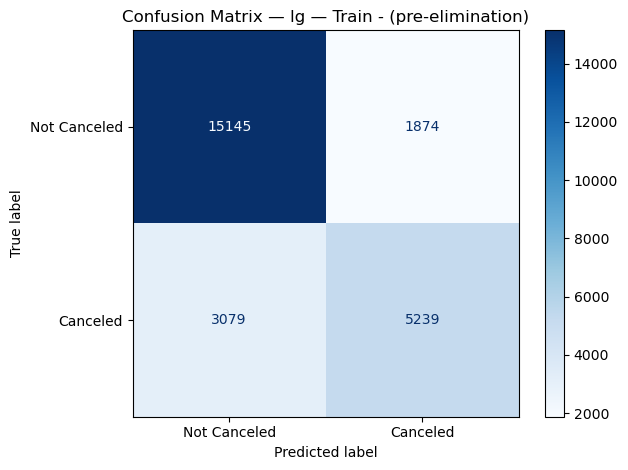

In [143]:
#Model Performance Check
# Note: lg included for comparison only — not a candidate model.
# Features with p > 0.05 and NaN p-values not yet removed.
results.append(evaluate_model('lg — Train - (pre-elimination)', lg, X_train_const, y_train))

### Removing High P-Values

In [144]:
# Drop Complementary
cols_to_drop = ['market_segment_type_Complementary']

X_train_lg2 = X_train_const.drop(cols_to_drop, axis=1)
X_test_lg2  = X_test_const.drop(cols_to_drop, axis=1)

# Refit model
logit2 = sm.Logit(y_train, X_train_lg2)
lg2 = logit2.fit(disp=False, maxiter=500)
print(lg2.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25337
Model:                          Logit   Df Residuals:                    25311
Method:                           MLE   Df Model:                           25
Date:                Wed, 17 Jun 2026   Pseudo R-squ.:                  0.3312
Time:                        16:20:59   Log-Likelihood:                -10725.
converged:                       True   LL-Null:                       -16037.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -2.8190      0.245    -11.509      0.000      -3.299      -2.339
no_of_adults                             0.0215      

In [145]:
#Drop Room Type 3
cols_to_drop = ['room_type_reserved_Room_Type 3']
X_train_lg3 = X_train_lg2.drop(cols_to_drop, axis=1)
X_test_lg3  = X_test_lg2.drop(cols_to_drop, axis=1)

logit3 = sm.Logit(y_train, X_train_lg3)
lg3 = logit3.fit(disp=False, maxiter=500)
print(lg3.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25337
Model:                          Logit   Df Residuals:                    25312
Method:                           MLE   Df Model:                           24
Date:                Wed, 17 Jun 2026   Pseudo R-squ.:                  0.3312
Time:                        16:20:59   Log-Likelihood:                -10725.
converged:                       True   LL-Null:                       -16037.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -2.8190      0.245    -11.509      0.000      -3.299      -2.339
no_of_adults                             0.0215      

To save time I will loop through dropping until all P values are <.05

In [146]:
lg_final, X_train_lgf, X_test_lgf = backward_elimination(X_train_lg3, X_test_lg3, y_train)
print(lg_final.summary())

Iteration 1: Dropping 'arrival_date' (p=0.9389)
Iteration 2: Dropping 'market_segment_type_Online' (p=0.7121)
Iteration 3: Dropping 'no_of_adults' (p=0.5375)
Iteration 4: Dropping 'type_of_meal_plan_Meal Plan 3' (p=0.2752)
Iteration 5: Dropping 'type_of_meal_plan_Meal Plan 2' (p=0.2554)
Iteration 6: Dropping 'no_of_previous_bookings_not_canceled' (p=0.1433)
All features significant. Final model reached in 6 iterations.
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25337
Model:                          Logit   Df Residuals:                    25318
Method:                           MLE   Df Model:                           18
Date:                Wed, 17 Jun 2026   Pseudo R-squ.:                  0.3310
Time:                        16:21:00   Log-Likelihood:                -10729.
converged:                       True   LL-Null:                       -16037.
Covariance Type:        

#### Notes on the final model parameters:

In [147]:
#Converting coefficients to Odds
odds = np.exp(lg_final.params)
print(odds)

const                            0.07
no_of_children                   1.16
no_of_weekend_nights             1.18
no_of_week_nights                1.03
required_car_parking_space       0.21
lead_time                        1.02
arrival_month                    0.94
repeated_guest                   0.06
no_of_previous_cancellations     1.29
avg_price_per_room               1.02
no_of_special_requests           0.22
type_of_meal_plan_Not Selected   1.38
room_type_reserved_Room_Type 2   0.64
room_type_reserved_Room_Type 4   0.84
room_type_reserved_Room_Type 5   0.44
room_type_reserved_Room_Type 6   0.36
room_type_reserved_Room_Type 7   0.33
market_segment_type_Corporate    0.40
market_segment_type_Offline      0.16
dtype: float64


##### Observations
The above displays the odds change given a unit change in a particular variable, holding all other variables constant.
- Bookings with no meal plan selected are 38% more likely to cancel
- Each previous cancellation increases cancellation odds by 29%
- Odds of cancellation increase with number of weekend nights
- Repeated guests are 94% less likely to cancel
- Offline bookings are 84% less likely to cancel
- Guests who require parking are 79% less likely to cancel
- Each additional special request reduces the odds of cancellation by 78%
- Each additional day between booking and arrival increases cancellation odds by 2%

## Model performance evaluation

  Model: lg_final — Train - .5 Threshold
  Accuracy         0.8043
  Recall           0.6295
  Precision        0.7361
  F1 Score         0.6786
  ROC-AUC          0.8640


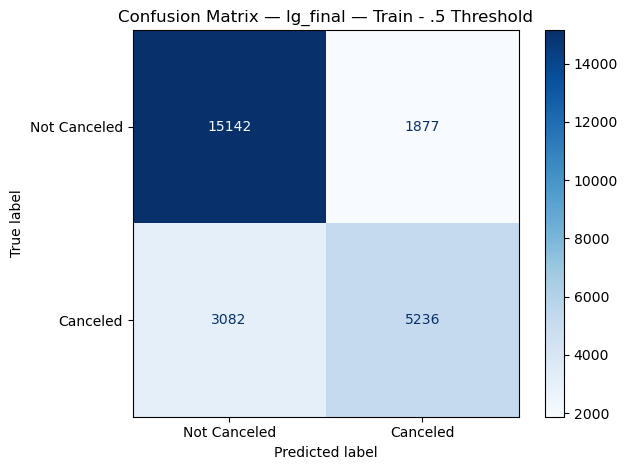

In [148]:
#Model Performance Check
results.append(evaluate_model('lg_final — Train - .5 Threshold', lg_final, X_train_lgf, y_train))

### ROC Curve

Optimal Threshold: 0.3130


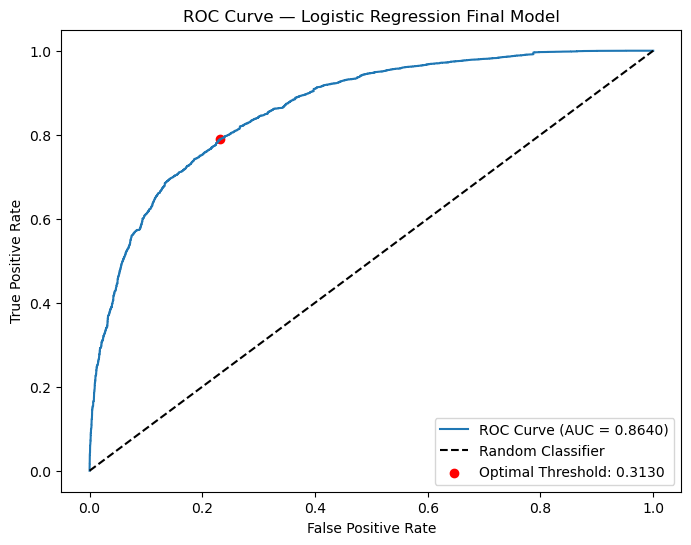

In [149]:
# Plot ROC curve and find optimal threshold
fpr, tpr, thresholds = roc_curve(y_train, lg_final.predict(X_train_lgf))

# Find optimal threshold
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Threshold: {optimal_threshold:.4f}")

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_train, lg_final.predict(X_train_lgf)):.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', 
            label=f'Optimal Threshold: {optimal_threshold:.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression Final Model')
plt.legend()
plt.show()

  Model: lg_final — Train - .313 Threshold
  Accuracy         0.7756
  Recall           0.7889
  Precision        0.6254
  F1 Score         0.6977
  ROC-AUC          0.8640


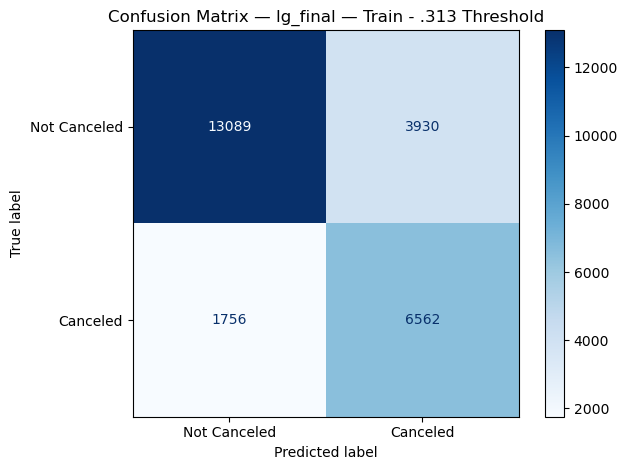

In [150]:
#Check ROC Optimal Threshold
results.append(evaluate_model('lg_final — Train - .313 Threshold', lg_final, X_train_lgf, y_train, threshold=.313))

### Precision - Recall

Optimal Threshold (F1): 0.4390


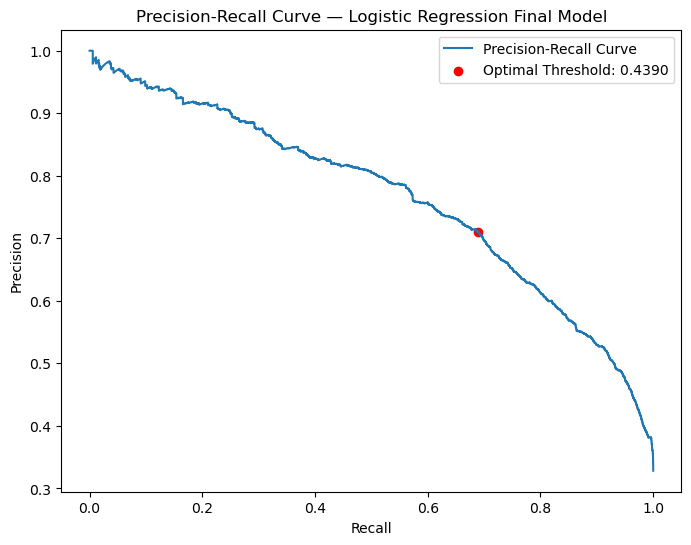

In [151]:
precision, recall, thresholds_pr = precision_recall_curve(y_train, lg_final.predict(X_train_lgf))

# Find threshold that maximizes F1
f1_scores = 2 * (precision * recall) / (precision + recall)
optimal_idx = np.argmax(f1_scores)
optimal_threshold_pr = thresholds_pr[optimal_idx]
print(f"Optimal Threshold (F1): {optimal_threshold_pr:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.scatter(recall[optimal_idx], precision[optimal_idx], 
            color='red', label=f'Optimal Threshold: {optimal_threshold_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Logistic Regression Final Model')
plt.legend()
plt.show()

  Model: lg_final — Train - .439 Threshold
  Accuracy         0.8057
  Recall           0.6899
  Precision        0.7101
  F1 Score         0.6999
  ROC-AUC          0.8640


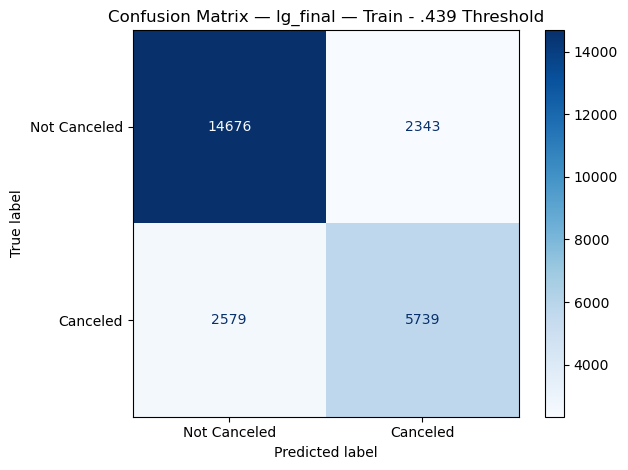

In [152]:
#Check Precision-Recall Optimal Threshold
results.append(evaluate_model('lg_final — Train - .439 Threshold', lg_final, X_train_lgf, y_train, threshold=.439))

In [153]:
# Display comparison table for Training Data
results_df = pd.DataFrame(results).set_index('Model')
results_df.T.style.format("{:.4f}")

Model,lg — Train - (pre-elimination),lg_final — Train - .5 Threshold,lg_final — Train - .313 Threshold,lg_final — Train - .439 Threshold
Accuracy,0.8045,0.8043,0.7756,0.8057
Recall,0.6298,0.6295,0.7889,0.6899
Precision,0.7365,0.7361,0.6254,0.7101
F1 Score,0.6790,0.6786,0.6977,0.6999
ROC-AUC,0.8645,0.8640,0.8640,0.8640


  Model: lg_final — Test  0.500
  Accuracy         0.7959
  Recall           0.6219
  Precision        0.7186
  F1 Score         0.6668
  ROC-AUC          0.8576


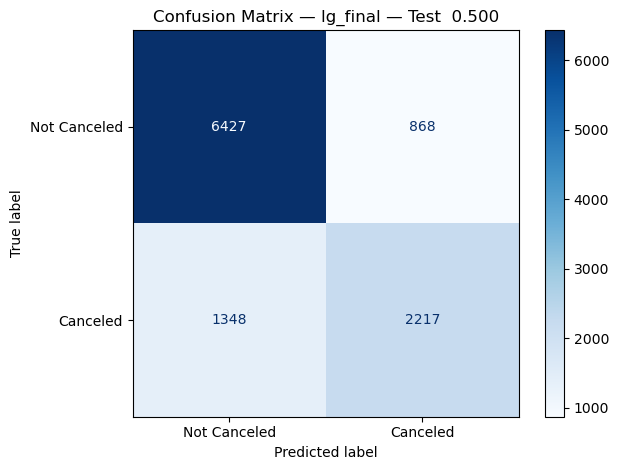

In [154]:
#Run Final Model on Test data with .5 threshold
results.append(evaluate_model('lg_final — Test  0.500', lg_final, X_test_lgf, y_test, threshold=0.500))

  Model: lg_final — Test  0.313
  Accuracy         0.7717
  Recall           0.7871
  Precision        0.6200
  F1 Score         0.6936
  ROC-AUC          0.8576


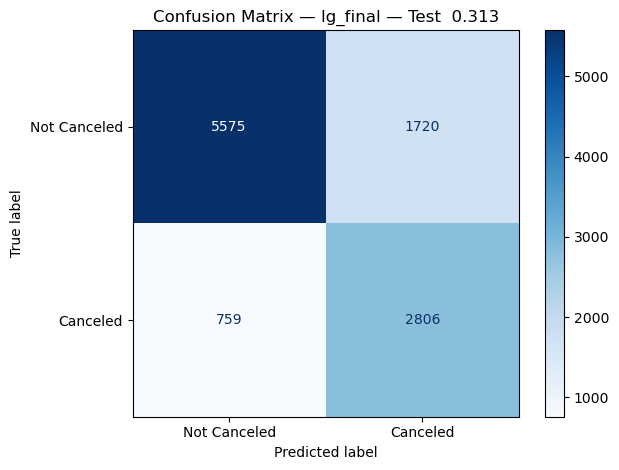

In [155]:
#Run Final Model on Test data with .313 threshold
results.append(evaluate_model('lg_final — Test  0.313', lg_final, X_test_lgf, y_test, threshold=0.313))

  Model: lg_final — Test  0.439
  Accuracy         0.7969
  Recall           0.6839
  Precision        0.6932
  F1 Score         0.6885
  ROC-AUC          0.8576


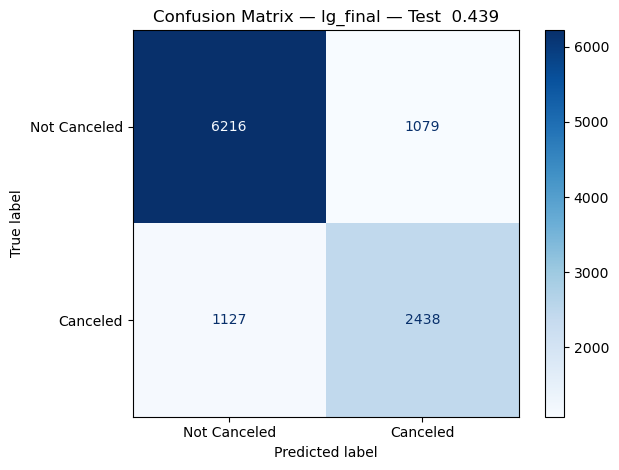

In [156]:
#Run Final Model on Test data with .439 threshold
results.append(evaluate_model('lg_final — Test  0.439', lg_final, X_test_lgf, y_test, threshold=0.439))

## Final Model Summary

In [157]:
# Display comparison table for Training and Test Data
results_df = pd.DataFrame(results).set_index('Model')
results_df.T.style.format("{:.4f}")

Model,lg — Train - (pre-elimination),lg_final — Train - .5 Threshold,lg_final — Train - .313 Threshold,lg_final — Train - .439 Threshold,lg_final — Test 0.500,lg_final — Test 0.313,lg_final — Test 0.439
Accuracy,0.8045,0.8043,0.7756,0.8057,0.7959,0.7717,0.7969
Recall,0.6298,0.6295,0.7889,0.6899,0.6219,0.7871,0.6839
Precision,0.7365,0.7361,0.6254,0.7101,0.7186,0.6200,0.6932
F1 Score,0.6790,0.6786,0.6977,0.6999,0.6668,0.6936,0.6885
ROC-AUC,0.8645,0.8640,0.8640,0.8640,0.8576,0.8576,0.8576


#### Final Selection:
The 0.439 threshold produces the highest F1 score on training data (0.6999) and was selected as the optimal threshold based on the objective of maximizing F1. However on test data the 0.313 threshold marginally outperforms on F1 (0.6936 vs 0.6885), though at a meaningful cost to precision (0.6200 vs 0.6932). Given the business objective of protecting brand as well as revenue — which requires balancing false positives and false negatives — the 0.439 threshold remains the recommended operating point as it better reflects that balance point.

## Building a Decision Tree model

### Unpruned Model

In [158]:
#Building initial unpruned model
dTree_unpruned = DecisionTreeClassifier(criterion = 'gini', random_state=1)
dTree_unpruned.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

  Model: dTree_unpruned - Train
  Accuracy         0.9940
  Recall           0.9903
  Precision        0.9913
  F1 Score         0.9908
  ROC-AUC          0.9999


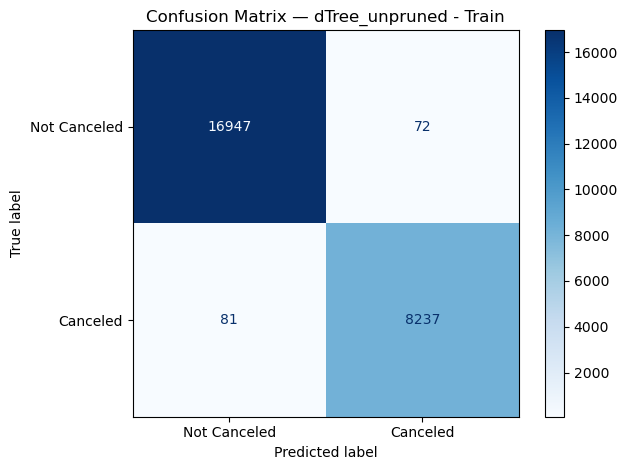

In [159]:
#Evaluate Model on Training Data
results.append(evaluate_model('dTree_unpruned - Train', dTree_unpruned, X_train, y_train))

  Model: dTree_unpruned - Test
  Accuracy         0.8647
  Recall           0.8020
  Precision        0.7893
  F1 Score         0.7956
  ROC-AUC          0.8514


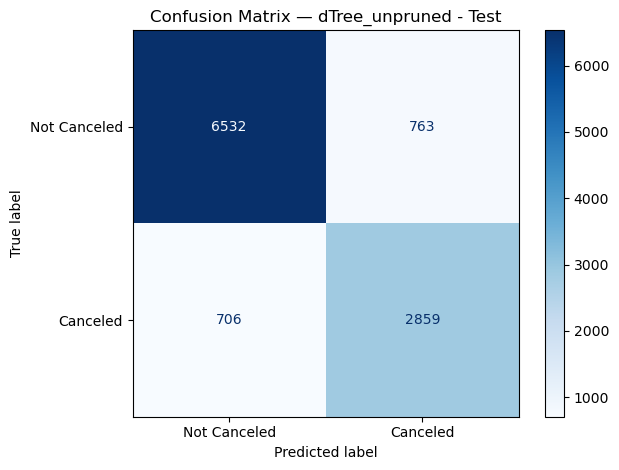

In [160]:
#Evaluate Model on Test Data
results.append(evaluate_model('dTree_unpruned - Test', dTree_unpruned, X_test, y_test))

In [161]:
#Create Feature Names to display Decision Tree
feature_names = list(X.columns)

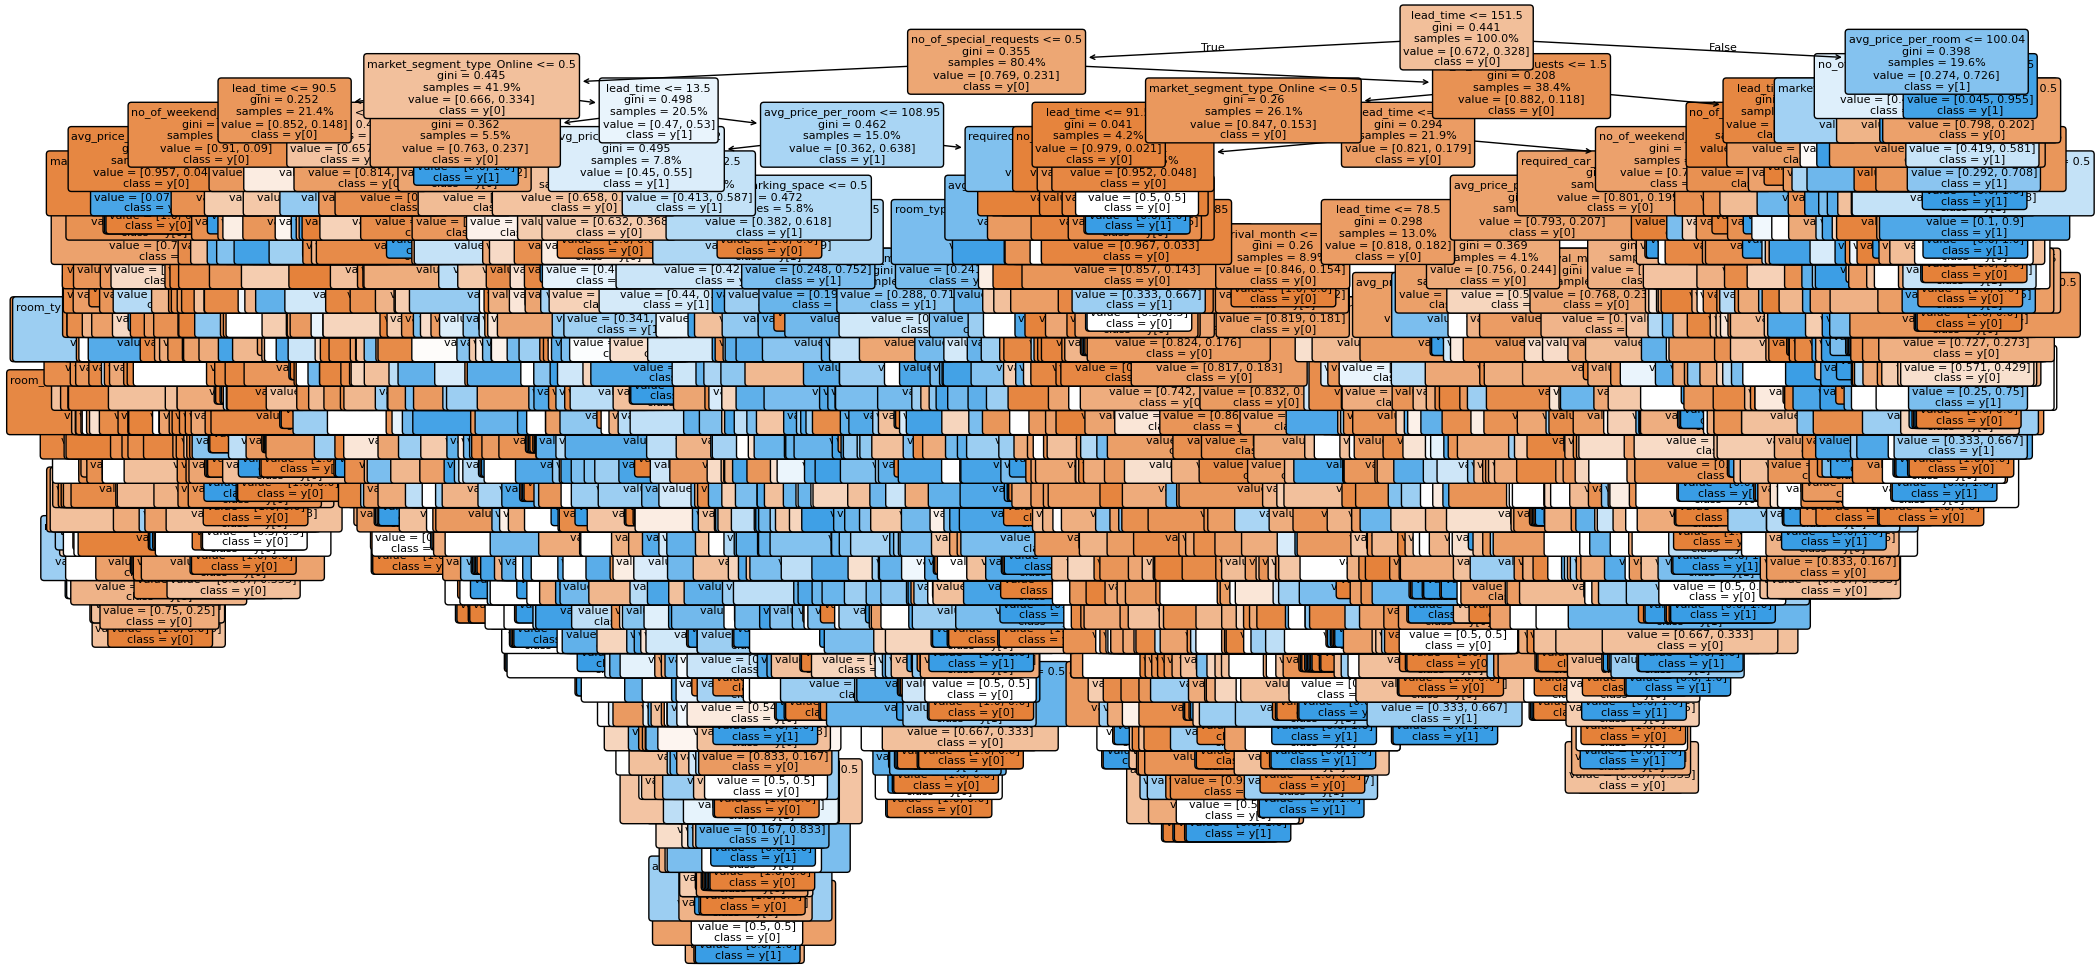

In [162]:
#Display Unpruned Decision Tree
plt.figure(figsize=(24,12))
tree.plot_tree(dTree_unpruned,feature_names=feature_names,filled=True,rounded=True,fontsize=8,node_ids=False,class_names=True,proportion=True)
plt.show()

In [163]:
# Importance of features listed
print (pd.DataFrame(dTree_unpruned.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

                                      Imp
lead_time                            0.36
avg_price_per_room                   0.18
market_segment_type_Online           0.10
arrival_date                         0.08
no_of_special_requests               0.07
arrival_month                        0.07
no_of_week_nights                    0.04
no_of_weekend_nights                 0.04
no_of_adults                         0.03
room_type_reserved_Room_Type 4       0.01
type_of_meal_plan_Not Selected       0.01
required_car_parking_space           0.01
no_of_children                       0.01
type_of_meal_plan_Meal Plan 2        0.00
market_segment_type_Offline          0.00
room_type_reserved_Room_Type 5       0.00
room_type_reserved_Room_Type 2       0.00
room_type_reserved_Room_Type 6       0.00
no_of_previous_bookings_not_canceled 0.00
repeated_guest                       0.00
room_type_reserved_Room_Type 7       0.00
room_type_reserved_Room_Type 3       0.00
market_segment_type_Corporate     

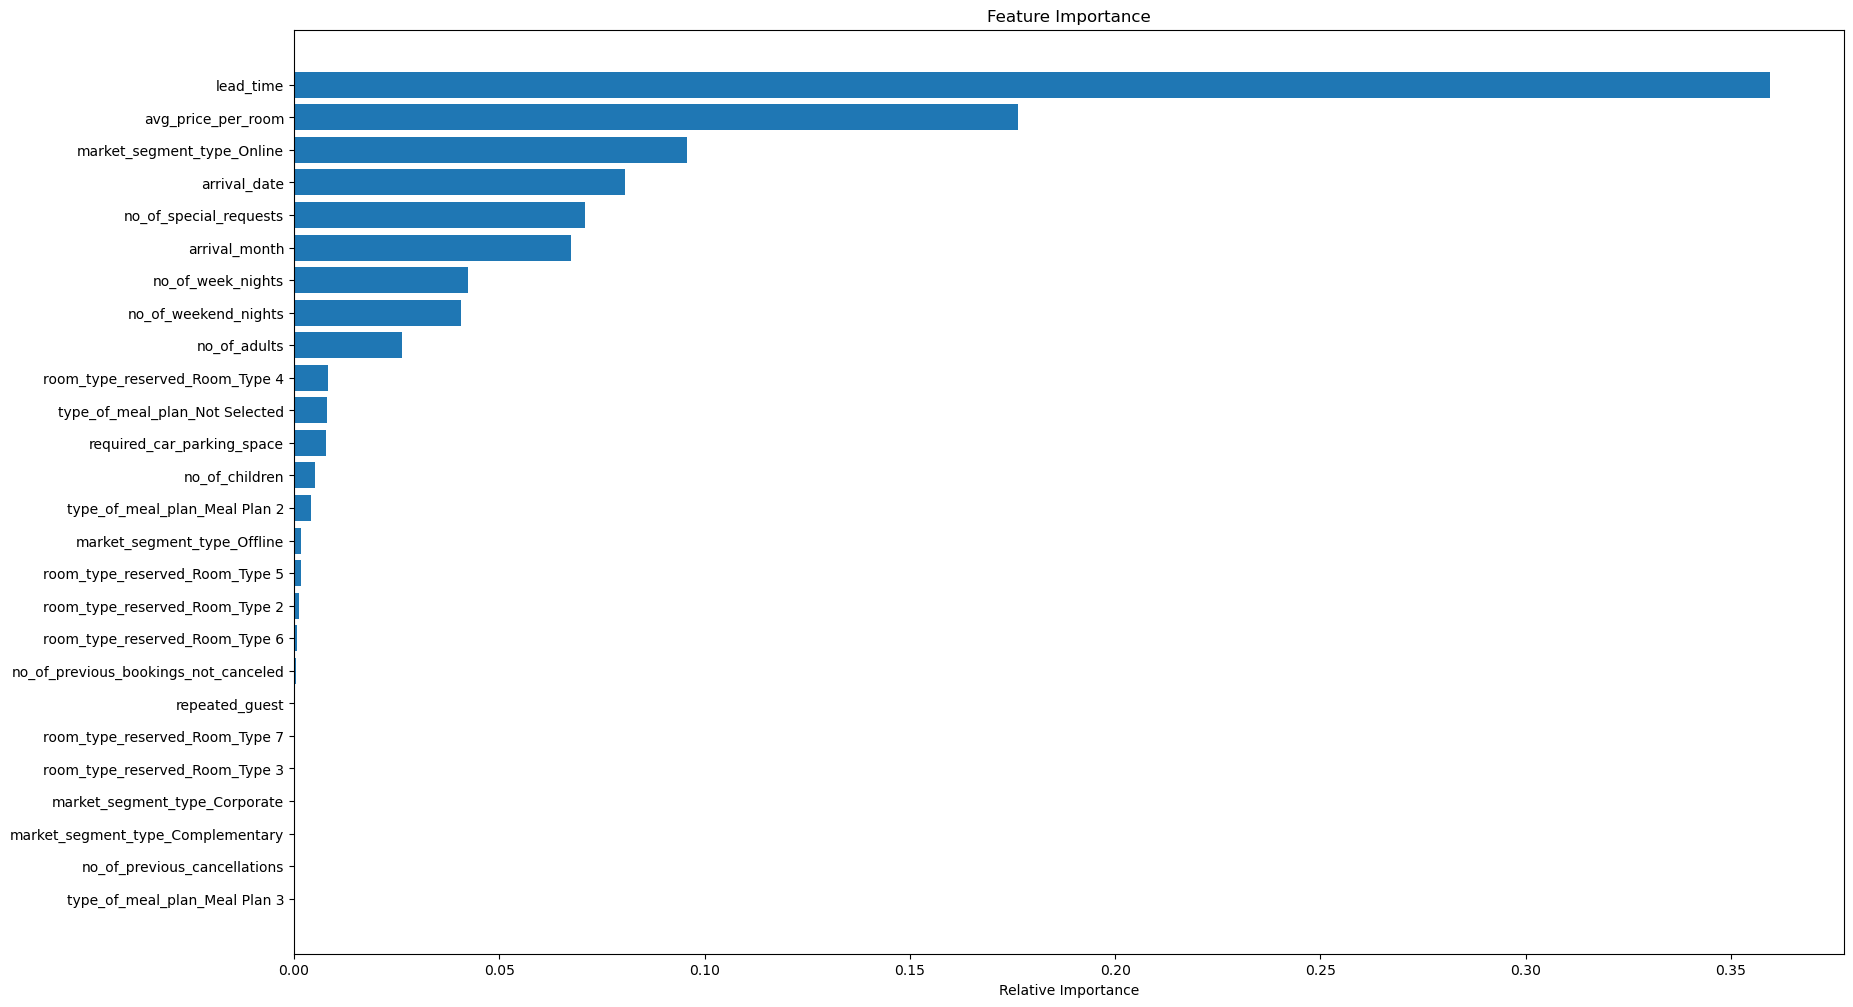

In [164]:
# Importance of features visual
importances = dTree_unpruned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(20,12))
plt.title('Feature Importance')
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

#### Unpruned Decision Tree Observations:
- As expected, the unpruned model performs extremely well on training data, but only moderately well on test data as it was allowed to overfit.
- We will test various pruning methods to see if we can develop a more balanced model that performs well on Test data and better meets the goal of protecting brand and revenue (balancing false positives and false negatives)
- It is worth noting that even without pruning, this model of decision tree outperforms the Logistic Regression models developed above.

### Prepruned Model

In [165]:
# Pre-pruning by hyperparameter tuning
dTree_Preprune = DecisionTreeClassifier(random_state=1)

# Grid of parameters to test
# max_depth: controls how deep the tree can grow
# min_samples_leaf: minimum samples required at a leaf node - higher = more generalization
# min_impurity_decrease: minimum impurity reduction required to make a split
parameters = {
    'max_depth': np.arange(1, 21),
    'min_samples_leaf': [1, 2, 5, 10, 15, 20, 50],
    'min_impurity_decrease': [0.0001, 0.001, 0.01, 0.1]
}

# F1 scorer — balances precision and recall per business objective
f1_scorer = make_scorer(f1_score)

# Grid Search with 5-fold cross validation
# cv=5 is standard - with 25k training rows each fold has ~20k rows
grid_search = GridSearchCV(
    estimator=dTree_Preprune,
    param_grid=parameters,
    scoring=f1_scorer,
    cv=5,
    n_jobs=-1,        # use all available CPU cores to speed up search
    verbose=1         # prints progress while running
)

grid_search.fit(X_train, y_train)

# Extract best model
dTree_Preprune = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 560 candidates, totalling 2800 fits
Best Parameters: {'max_depth': np.int64(15), 'min_impurity_decrease': 0.0001, 'min_samples_leaf': 1}
Best CV F1 Score: 0.8003


  Model: dTree_Preprune - Train
  Accuracy         0.8988
  Recall           0.8123
  Precision        0.8706
  F1 Score         0.8405
  ROC-AUC          0.9530


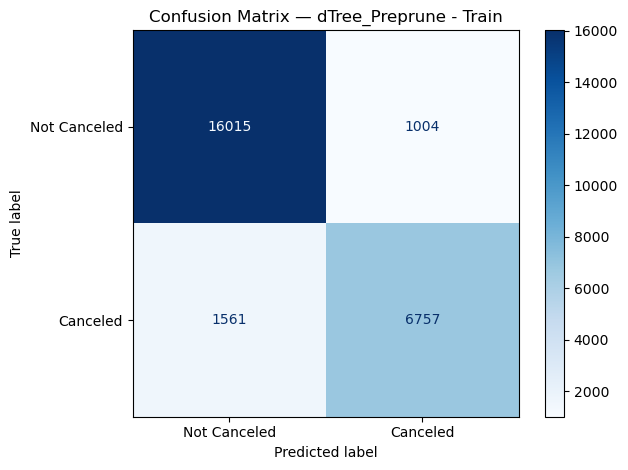

In [166]:
#Evaluate Prepruned Model on Training Data
results.append(evaluate_model('dTree_Preprune - Train', dTree_Preprune, X_train, y_train))

  Model: dTree_Preprune - Test
  Accuracy         0.8710
  Recall           0.7669
  Precision        0.8275
  F1 Score         0.7960
  ROC-AUC          0.9280


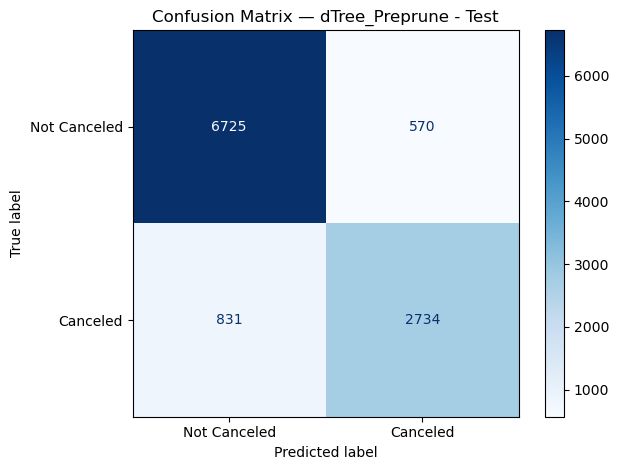

In [167]:
#Evaluate Prepruned Model on Test Data
results.append(evaluate_model('dTree_Preprune - Test', dTree_Preprune, X_test, y_test))

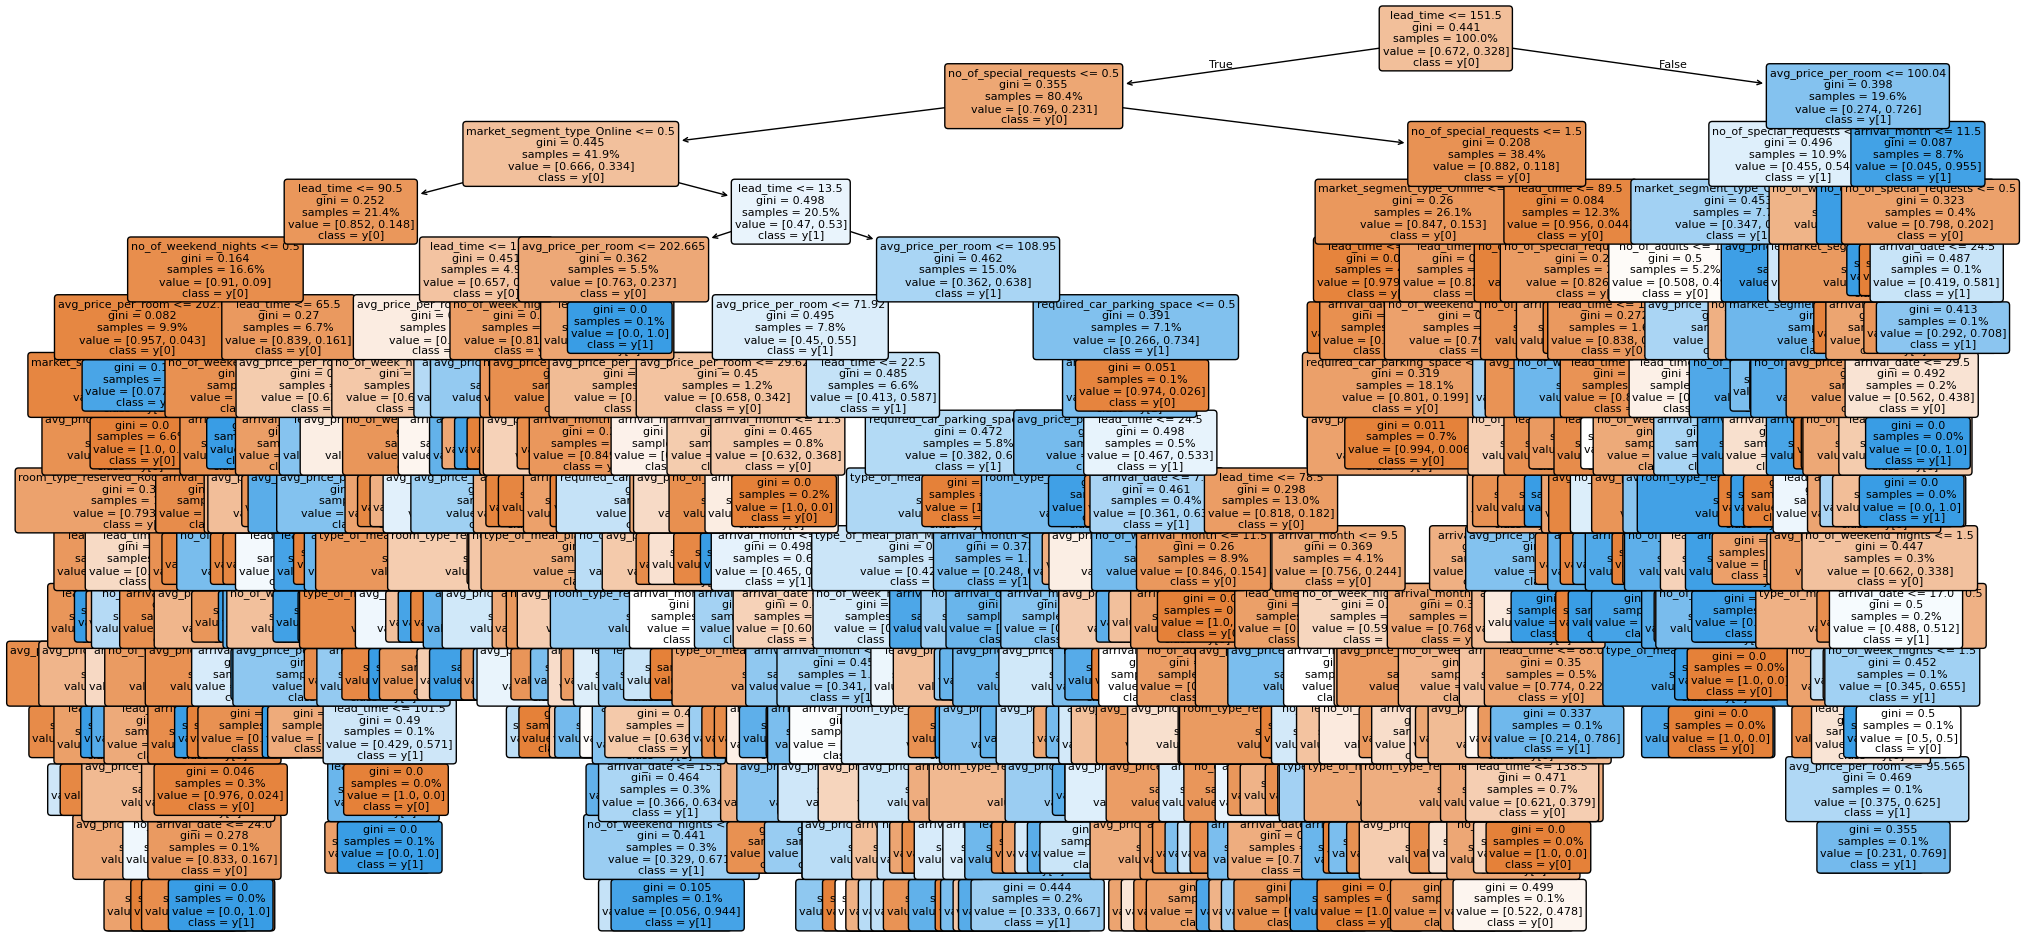

In [168]:
#Display Prepruned Decision Tree
plt.figure(figsize=(24,12))
tree.plot_tree(dTree_Preprune,feature_names=feature_names,filled=True,rounded=True,fontsize=8,node_ids=False,class_names=True,proportion=True)
plt.show()

In [169]:
# Importance of features listed
print (pd.DataFrame(dTree_Preprune.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

                                      Imp
lead_time                            0.41
avg_price_per_room                   0.15
market_segment_type_Online           0.14
no_of_special_requests               0.11
arrival_month                        0.06
no_of_weekend_nights                 0.03
arrival_date                         0.03
no_of_adults                         0.02
no_of_week_nights                    0.02
required_car_parking_space           0.01
type_of_meal_plan_Not Selected       0.01
room_type_reserved_Room_Type 4       0.00
type_of_meal_plan_Meal Plan 2        0.00
room_type_reserved_Room_Type 5       0.00
market_segment_type_Offline          0.00
no_of_children                       0.00
room_type_reserved_Room_Type 2       0.00
repeated_guest                       0.00
no_of_previous_cancellations         0.00
room_type_reserved_Room_Type 3       0.00
no_of_previous_bookings_not_canceled 0.00
type_of_meal_plan_Meal Plan 3        0.00
room_type_reserved_Room_Type 7    

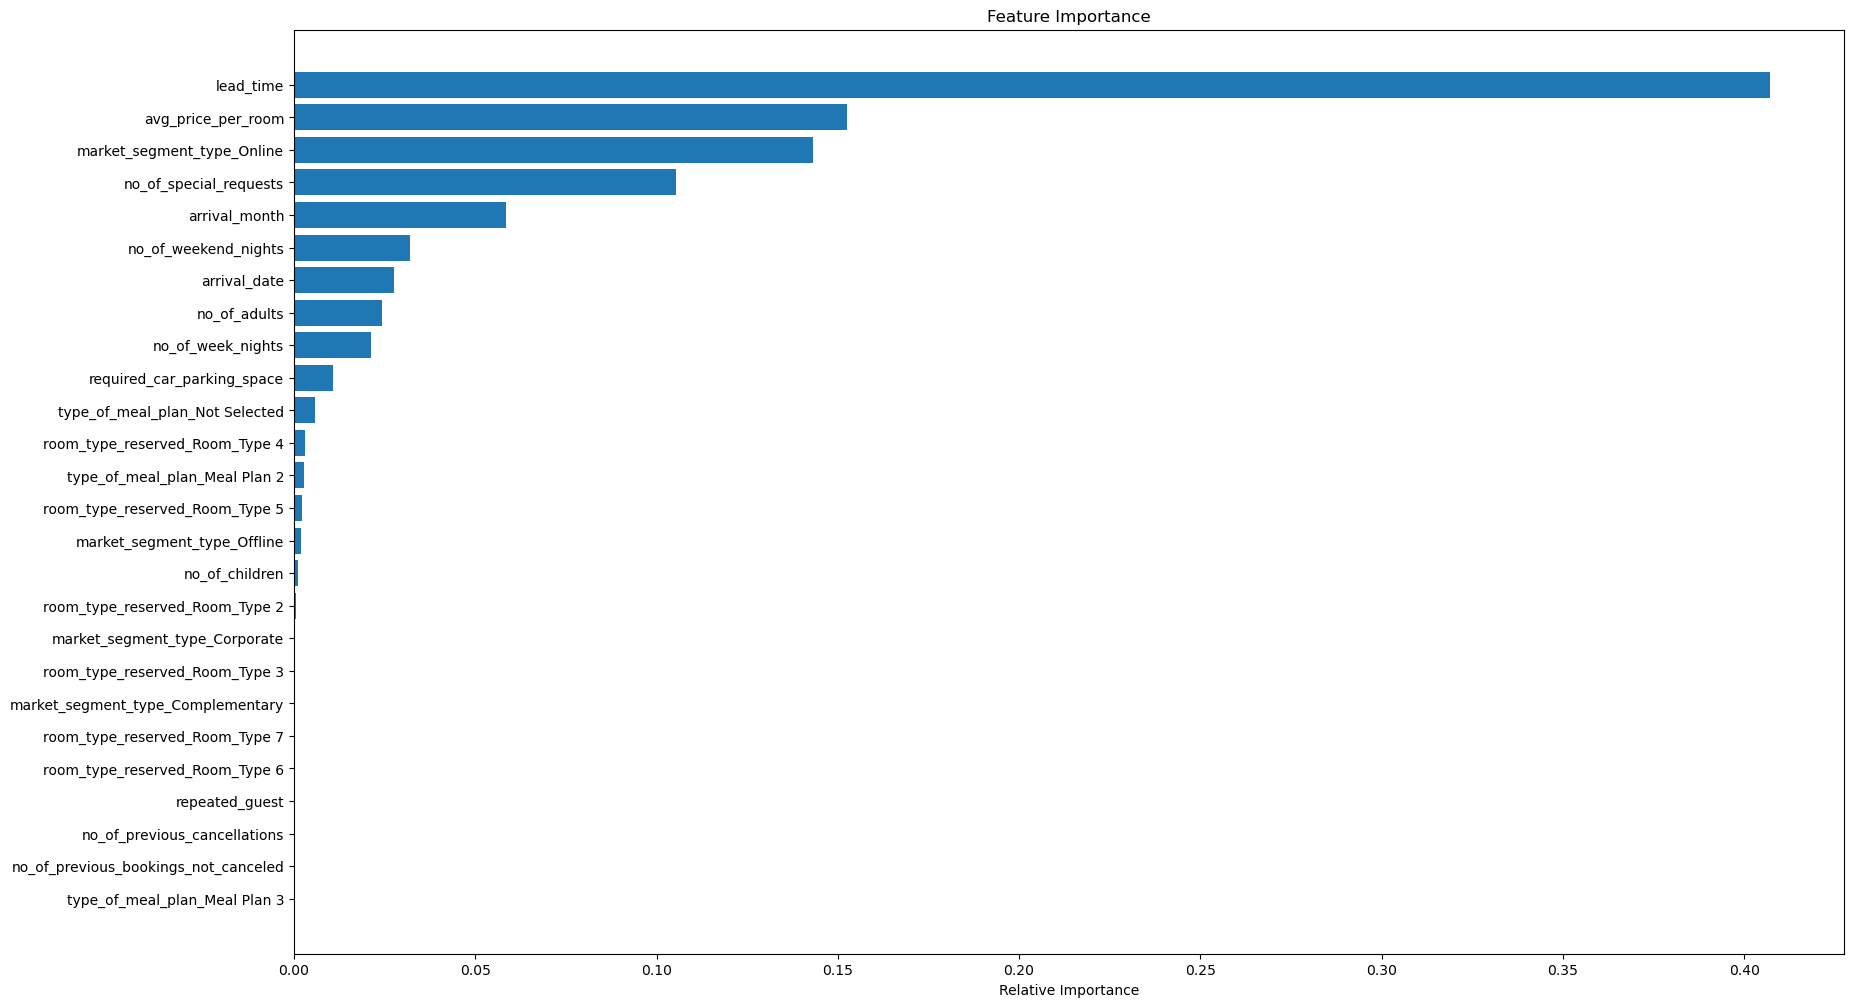

In [170]:
# Importance of features visual
importances = dTree_Preprune.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(20,12))
plt.title('Feature Importance')
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [171]:
#Compare Tree Size without pruning and with prepruning
print("Unpruned Tree Depth:", dTree_unpruned.get_depth())
print("Unpruned Tree Leaves:", dTree_unpruned.get_n_leaves())
print()
print("Pre-pruned Tree Depth:", dTree_Preprune.get_depth())
print("Pre-pruned Tree Leaves:", dTree_Preprune.get_n_leaves())

Unpruned Tree Depth: 37
Unpruned Tree Leaves: 2943

Pre-pruned Tree Depth: 15
Pre-pruned Tree Leaves: 298


In [172]:
# Display comparison of all models so far
results_df = pd.DataFrame(results).set_index('Model')
results_df.T.style.format("{:.4f}")

Model,lg — Train - (pre-elimination),lg_final — Train - .5 Threshold,lg_final — Train - .313 Threshold,lg_final — Train - .439 Threshold,lg_final — Test 0.500,lg_final — Test 0.313,lg_final — Test 0.439,dTree_unpruned - Train,dTree_unpruned - Test,dTree_Preprune - Train,dTree_Preprune - Test
Accuracy,0.8045,0.8043,0.7756,0.8057,0.7959,0.7717,0.7969,0.9940,0.8647,0.8988,0.8710
Recall,0.6298,0.6295,0.7889,0.6899,0.6219,0.7871,0.6839,0.9903,0.8020,0.8123,0.7669
Precision,0.7365,0.7361,0.6254,0.7101,0.7186,0.6200,0.6932,0.9913,0.7893,0.8706,0.8275
F1 Score,0.6790,0.6786,0.6977,0.6999,0.6668,0.6936,0.6885,0.9908,0.7956,0.8405,0.7960
ROC-AUC,0.8645,0.8640,0.8640,0.8640,0.8576,0.8576,0.8576,0.9999,0.8514,0.9530,0.9280


#### Prepruned Decision Tree Observations:
- Prepruning reduced the tree depth from 37 to 15 and reduced the number of leaves by 2,645 (~90%)
- The training and test data for the prepruned model are much closer than the unpruned model implying that this model has reduced the overfitting issue.
- F1 Score has only marginally improved on the test set.
- Precision improved on the Test set, but Recall performance declined.


### Postpruned Model

In [173]:
# Initialize unpruned tree to extract cost complexity pruning path
# Pruning path shows all possible alpha values and their associated impurities
# Alpha is the complexity parameter - higher alpha = more pruning = simpler tree
dt_pruning = DecisionTreeClassifier(random_state=1)
path = dt_pruning.cost_complexity_pruning_path(X_train, y_train)

# ccp_alphas: the effective alpha values at each pruning step
# impurities: total impurity of leaves at each pruning step
# abs() applied to prevent negative alpha errors downstream
ccp_alphas, impurities = abs(path.ccp_alphas), abs(path.impurities)

pd.DataFrame(path)

,ccp_alphas,impurities
0,0.00,0.01
1,0.00,0.01
2,0.00,0.01
3,0.00,0.01
4,0.00,0.01
...,...,...
1325,0.01,0.29
1326,0.01,0.30
1327,0.02,0.31
1328,0.02,0.36


In [174]:
# Build a tree for each alpha value to visualize pruning effect
pruning_trees = []
for ccp_alpha in ccp_alphas:
    dt = DecisionTreeClassifier(random_state=1, ccp_alpha=ccp_alpha)
    dt.fit(X_train, y_train)
    pruning_trees.append(dt)

print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
      pruning_trees[-1].tree_.node_count, ccp_alphas[-1]))

Number of nodes in the last tree is: 1 with ccp_alpha: 0.077461812981104


In [175]:
# Calculate F1 score for each pruned tree on train and test sets
# This shows how model performance changes as alpha increases

train_f1_scores = [
    f1_score(y_train, pt.predict(X_train)) 
    for pt in pruning_trees
]

test_f1_scores = [
    f1_score(y_test, pt.predict(X_test)) 
    for pt in pruning_trees
]

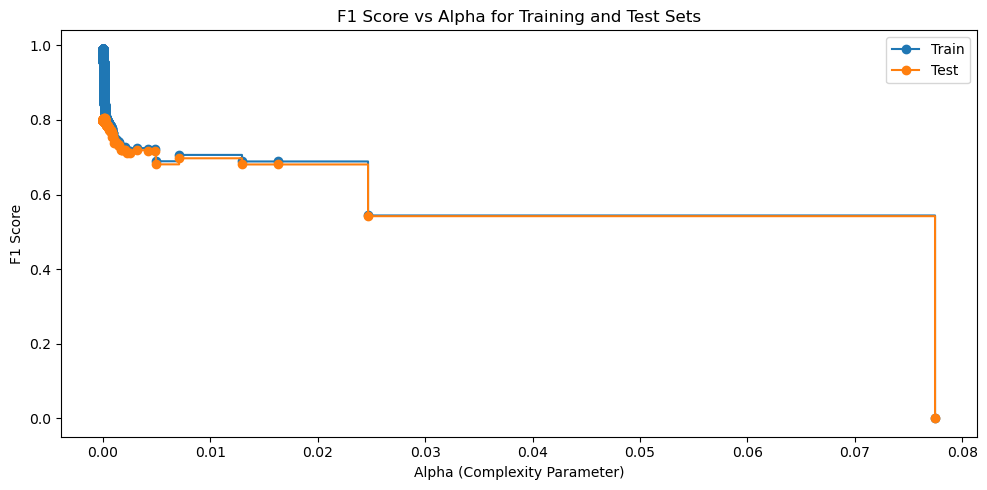

In [176]:
# Plot train vs test F1 across all alpha values
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlabel("Alpha (Complexity Parameter)")
ax.set_ylabel("F1 Score")
ax.set_title("F1 Score vs Alpha for Training and Test Sets")
ax.plot(ccp_alphas, train_f1_scores, marker='o', 
        label="Train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_f1_scores, marker='o', 
        label="Test", drawstyle="steps-post")
ax.legend()
plt.tight_layout()
plt.show()

The full range plot above shows the complete pruning path. The compressed scale makes it difficult to distinguish train and test performance — zooming into the region of interest reveals the separation more clearly:

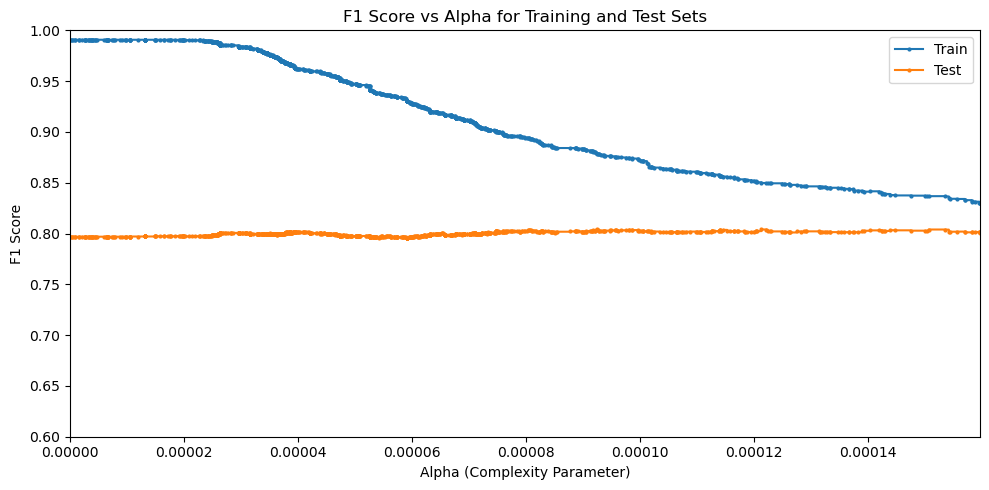

In [177]:
# Plot train vs test F1 across all alpha values
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlabel("Alpha (Complexity Parameter)")
ax.set_ylabel("F1 Score")
ax.set_title("F1 Score vs Alpha for Training and Test Sets")
ax.plot(ccp_alphas, train_f1_scores, marker='o', 
        label="Train", drawstyle="steps-post", markersize=2)
ax.plot(ccp_alphas, test_f1_scores, marker='o', 
        label="Test", drawstyle="steps-post", markersize=2)

# Zoom to meaningful region
ax.set_ylim(0.6, 1.0)
ax.set_xlim(0, ccp_alphas[1200])

ax.legend()
plt.tight_layout()
plt.show()

In [178]:
# Identify the alpha value that produces the best test F1 score
index_best_model = np.argmax(test_f1_scores)
best_alpha = ccp_alphas[index_best_model]

# Refit a final model using the optimal alpha
dTree_Postprune = DecisionTreeClassifier(random_state=1, ccp_alpha=best_alpha)
dTree_Postprune.fit(X_train, y_train)

print(f"Optimal Alpha: {best_alpha:.6f}")

Optimal Alpha: 0.000121


  Model: dTree_Postprune - Train
  Accuracy         0.9041
  Recall           0.8319
  Precision        0.8701
  F1 Score         0.8506
  ROC-AUC          0.9550


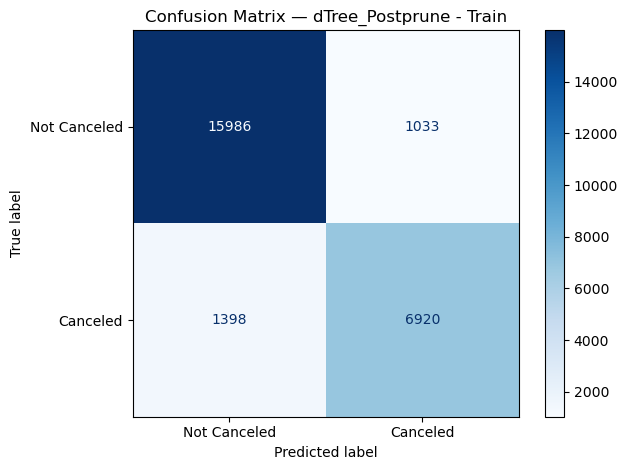

In [179]:
#Evaluate Postpruned Model on Training Data
results.append(evaluate_model('dTree_Postprune - Train', dTree_Postprune, X_train, y_train))

  Model: dTree_Postprune - Test
  Accuracy         0.8738
  Recall           0.7843
  Precision        0.8231
  F1 Score         0.8032
  ROC-AUC          0.9296


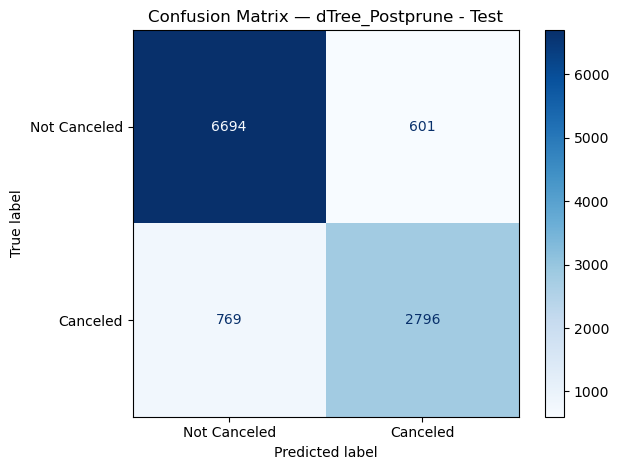

In [180]:
#Evaluate Postpruned Model on Test Data
results.append(evaluate_model('dTree_Postprune - Test', dTree_Postprune, X_test, y_test))

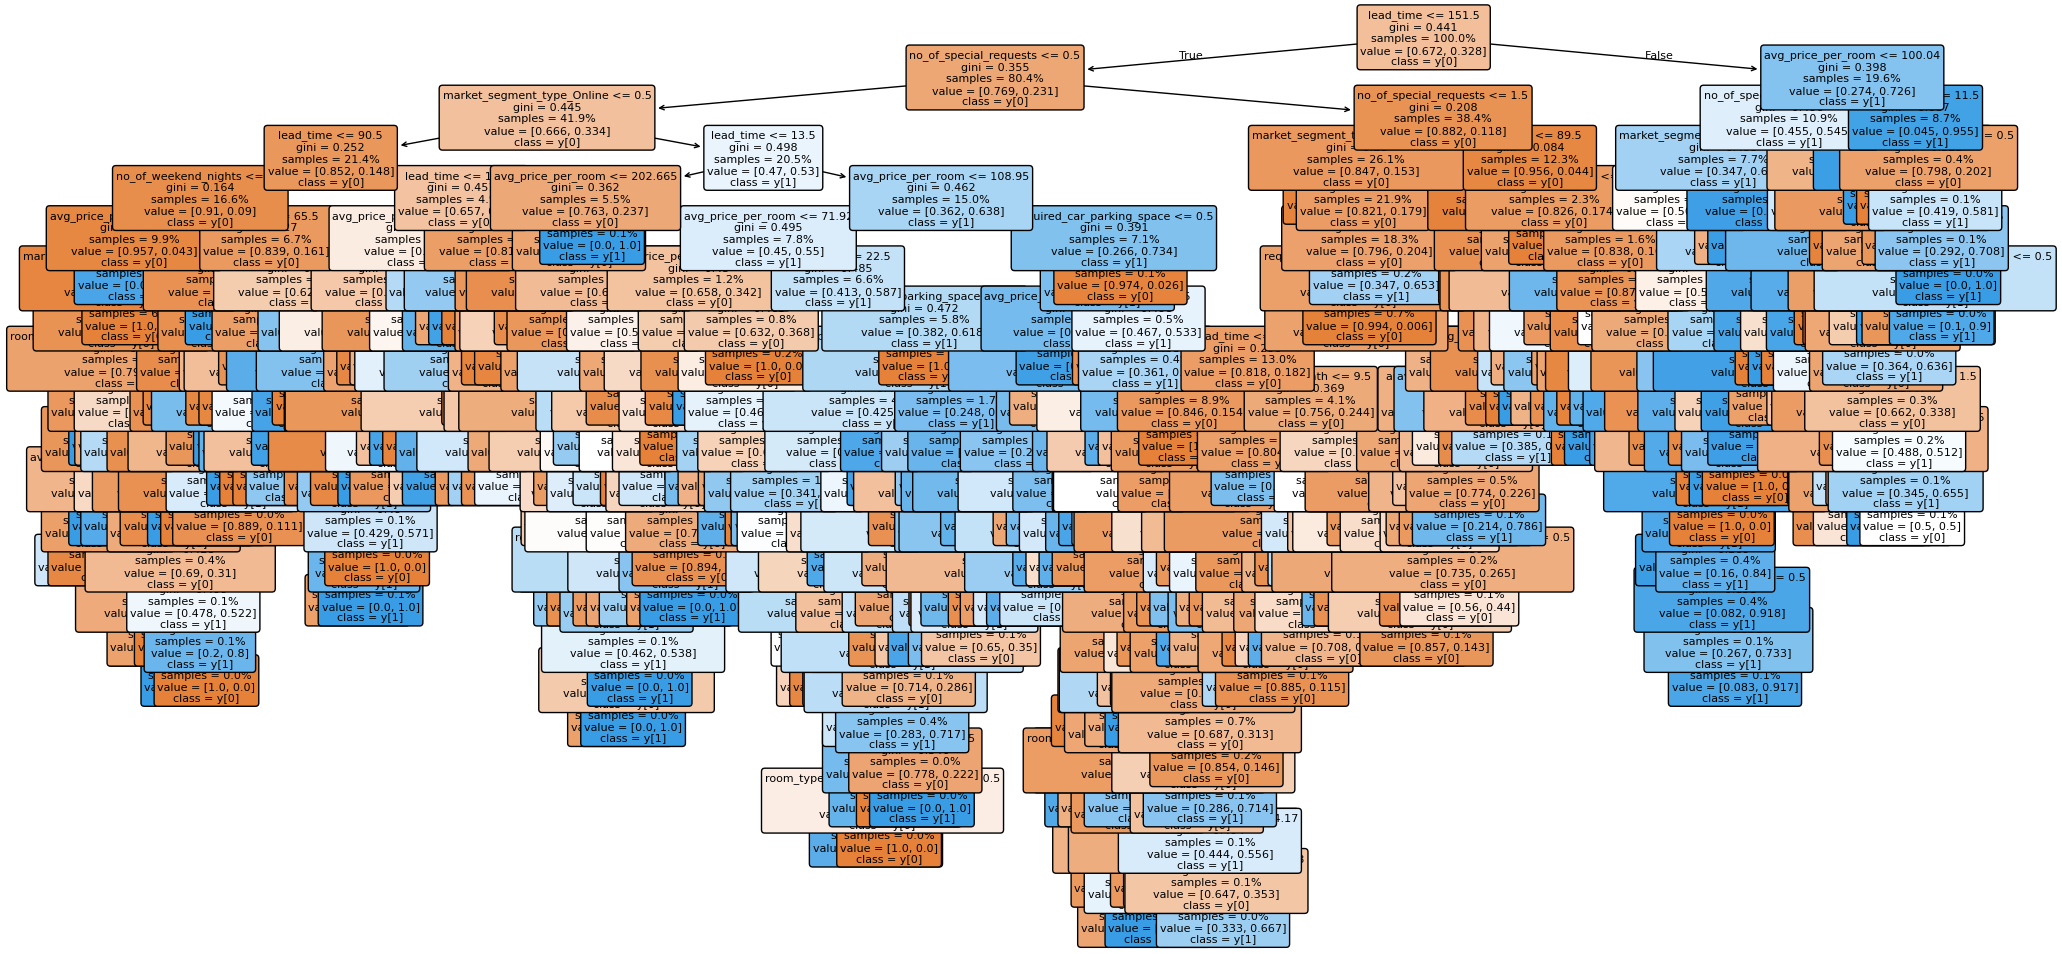

In [181]:
#Display Postpruned Decision Tree
plt.figure(figsize=(24,12))
tree.plot_tree(dTree_Postprune,feature_names=feature_names,filled=True,rounded=True,fontsize=8,node_ids=False,class_names=True,proportion=True)
plt.show()

In [182]:
# Importance of features listed
print (pd.DataFrame(dTree_Postprune.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

                                      Imp
lead_time                            0.41
avg_price_per_room                   0.16
market_segment_type_Online           0.14
no_of_special_requests               0.10
arrival_month                        0.06
no_of_weekend_nights                 0.03
arrival_date                         0.03
no_of_adults                         0.02
no_of_week_nights                    0.02
required_car_parking_space           0.01
type_of_meal_plan_Not Selected       0.01
room_type_reserved_Room_Type 4       0.00
type_of_meal_plan_Meal Plan 2        0.00
room_type_reserved_Room_Type 5       0.00
market_segment_type_Offline          0.00
no_of_children                       0.00
room_type_reserved_Room_Type 2       0.00
repeated_guest                       0.00
no_of_previous_cancellations         0.00
room_type_reserved_Room_Type 3       0.00
no_of_previous_bookings_not_canceled 0.00
type_of_meal_plan_Meal Plan 3        0.00
room_type_reserved_Room_Type 7    

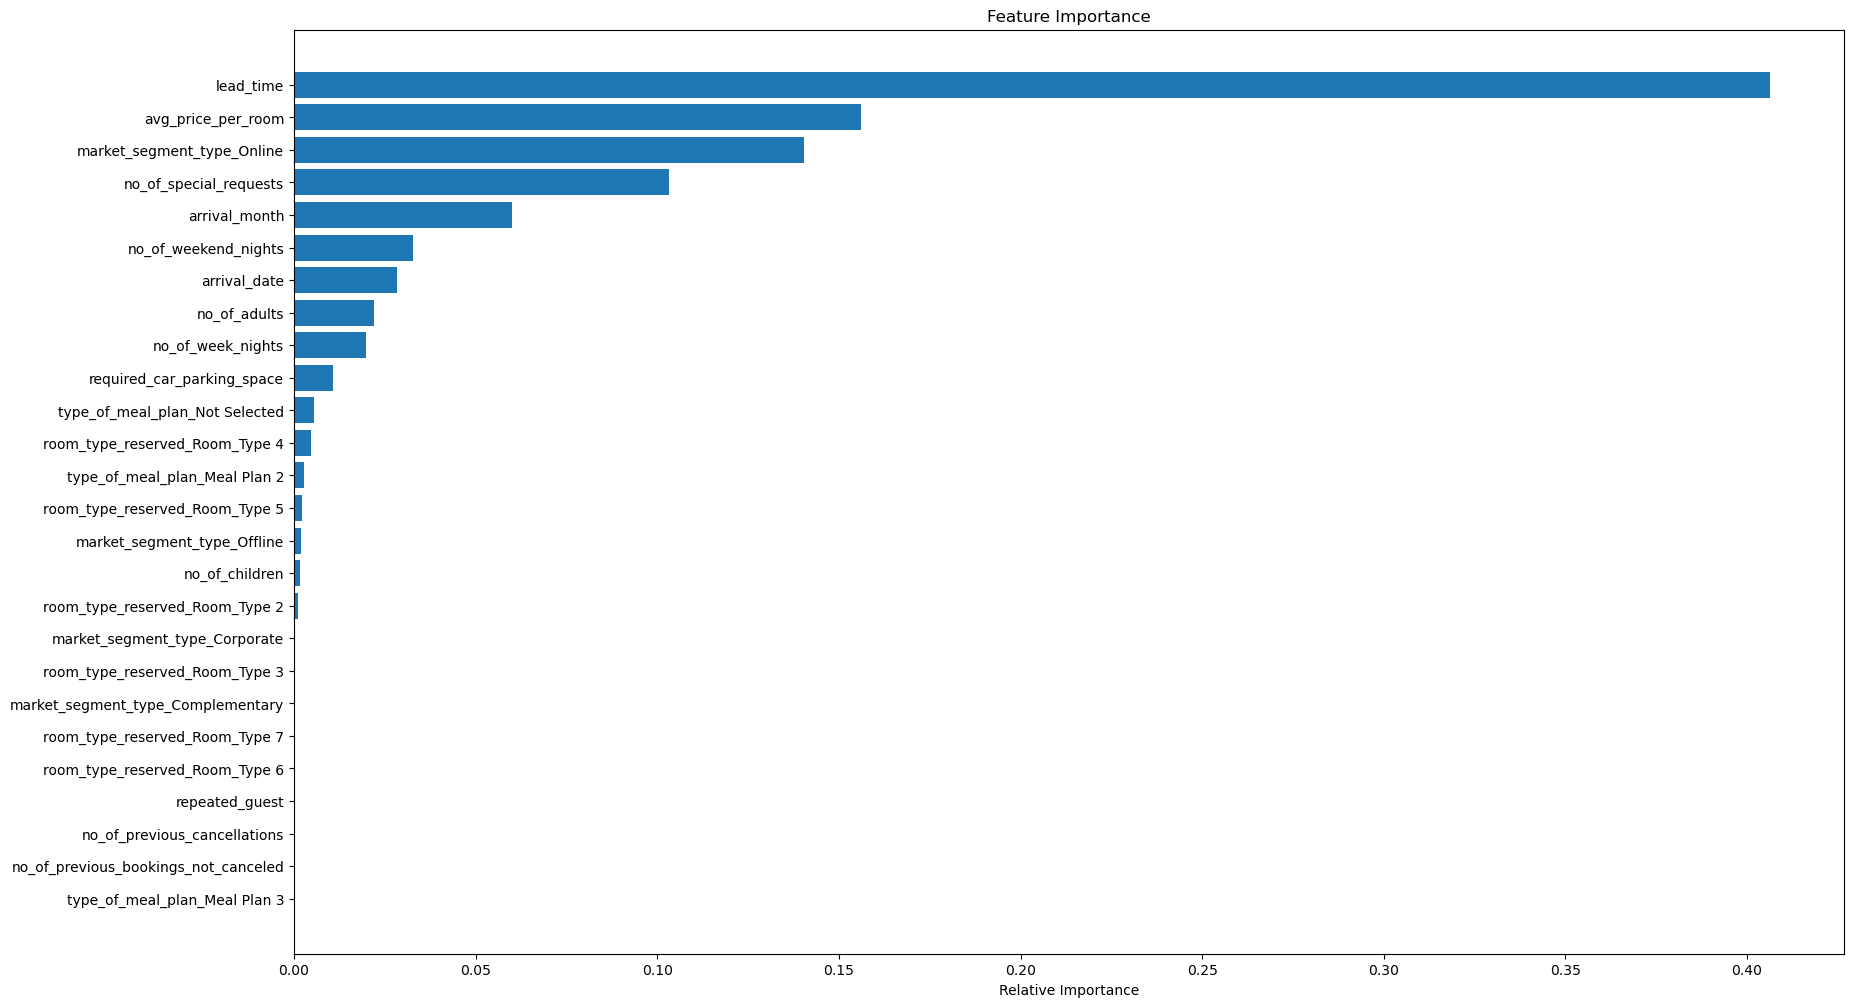

In [183]:
# Importance of features visual
importances = dTree_Postprune.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(20,12))
plt.title('Feature Importance')
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [184]:
#Compare Tree Size without pruning, with prepruning, with postpruning
print("Unpruned Tree Depth:", dTree_unpruned.get_depth())
print("Unpruned Tree Leaves:", dTree_unpruned.get_n_leaves())
print()
print("Pre-pruned Tree Depth:", dTree_Preprune.get_depth())
print("Pre-pruned Tree Leaves:", dTree_Preprune.get_n_leaves())
print()
print("Post-pruned Tree Depth:", dTree_Postprune.get_depth())
print("Post-pruned Tree Leaves:", dTree_Postprune.get_n_leaves())

Unpruned Tree Depth: 37
Unpruned Tree Leaves: 2943

Pre-pruned Tree Depth: 15
Pre-pruned Tree Leaves: 298

Post-pruned Tree Depth: 22
Post-pruned Tree Leaves: 321


In [185]:
# Display comparison of all models so far
results_df = pd.DataFrame(results).set_index('Model')
results_df.T.style.format("{:.4f}")

Model,lg — Train - (pre-elimination),lg_final — Train - .5 Threshold,lg_final — Train - .313 Threshold,lg_final — Train - .439 Threshold,lg_final — Test 0.500,lg_final — Test 0.313,lg_final — Test 0.439,dTree_unpruned - Train,dTree_unpruned - Test,dTree_Preprune - Train,dTree_Preprune - Test,dTree_Postprune - Train,dTree_Postprune - Test
Accuracy,0.8045,0.8043,0.7756,0.8057,0.7959,0.7717,0.7969,0.9940,0.8647,0.8988,0.8710,0.9041,0.8738
Recall,0.6298,0.6295,0.7889,0.6899,0.6219,0.7871,0.6839,0.9903,0.8020,0.8123,0.7669,0.8319,0.7843
Precision,0.7365,0.7361,0.6254,0.7101,0.7186,0.6200,0.6932,0.9913,0.7893,0.8706,0.8275,0.8701,0.8231
F1 Score,0.6790,0.6786,0.6977,0.6999,0.6668,0.6936,0.6885,0.9908,0.7956,0.8405,0.7960,0.8506,0.8032
ROC-AUC,0.8645,0.8640,0.8640,0.8640,0.8576,0.8576,0.8576,0.9999,0.8514,0.9530,0.9280,0.9550,0.9296


#### Postpruned Model Observations:
- The post pruned tree is slightly larger and more complex than the prepruned tree, but still much smaller and less complex than the unpruned tree.
- The F1 score of the postpruned tree is slightly better than the prepruned tree.
- The postpruned model has a slight decrease in precision but an accompanying increase in recall when compared with the prepruned model.
- Decision tree models substantially outperform logistic regression across all metrics on this dataset, suggesting the relationships between features and cancellation are non-linear in nature.

## Model Performance Comparison and Conclusions

- Comparing all models, the post-pruned decision tree best meets the designated business goals with the highest F1 score (balancing precision and recall) on the test data. 
- Of the models evaluated on test data it has the third best Recall.  In business terms, it was the third best at predicting true cancellations and minimizing false negatives. Only the 0.313 threshold logistic regression (0.7871) and the unpruned tree (0.8020) achieve higher recall on test data — both at significant cost to precision
- Of the models evaluated on test data it has the second best Precision.  In business terms, it was the second best at minimizing false cancellation flags (false positives).
- The unpruned tree achieves the highest recall (0.8020) among decision trees on test data but shows severe overfitting with a 0.1952 train/test F1 gap. The post-pruned tree reduces this gap to 0.0474 while maintaining competitive performance, making it the more reliable and generalizable model for production use.

## Actionable Insights and Recommendations

- What profitable policies for cancellations and refunds can the hotel adopt?
- What other recommendations would you suggest to the hotel?

### Insights
- 33% of bookings in the dataset were canceled.
- August to October have the most bookings.
- Repeat guests appear to be uncommon, making up only 2.6% of the guests in this dataset.
- Room Type 6 has the highest cancellation rate at 42%.
- July has the highest cancellation rate at 45%.
- While the post-pruned decision tree was selected as the best predictive model, logistic regression provides valuable directional insight into how individual factors influence cancellation odds. According to the Logistic Regression model:
  - Repeated guests are 94% less likely to cancel.
  - Guests who require parking are 79% less likely to cancel.
  - Each additional day of lead time increases cancellation odds by 2% — a booking made 100 days out has roughly twice the cancellation odds of a same-day booking.
  - Each additional special request reduces cancellation odds by 78%.
  - Offline bookings cancel 84% less than the baseline.
- The post-pruned decision tree best meets the designated business goals with the highest F1 score (balancing precision and recall) on the test data.  In business terms, it is best at balancing prediction of true cancellations, minimizing false negatives, and minimizing false cancellation flags.
- In our final model lead time is the most important feature for predicting cancellation followed by average price, market segment, and number of special requests.

### Recommendations
- Implement the recommended model (post-pruned decision tree) for cancellation prediction.
- Use model predictions to implement dynamic overbooking strategies, accepting additional reservations proportional to predicted cancellation rates to maximize room utilization.
  - Tighten guardrails against overbooking in months of August to October
- Consider stricter cancellation policies or non-refundable rate incentives for high lead time bookings, which the model identifies as the strongest cancellation predictor.

#### Further Study Recommendations
- Conduct analysis of what is driving the lack of repeat guests.
  - Start or improve loyalty programs
  - Improve advertising
- A/B Testing of Special Request Prompting: Guests who make special requests are 78% less likely to cancel. The direction of causality is unclear however:
  - More committed guests may naturally generate more requests — in which case special requests are a signal of intent, not a driver of it, and prompting for them would have no effect on cancellation rates.
  - Alternatively, the act of making requests may itself increase guest investment in the stay — in which case proactively prompting guests for preferences during booking could reduce cancellations.
  - A/B testing a prompted special requests workflow against the current booking process would resolve this ambiguity and is recommended before operational changes are made.